### LSE Data Analytics Online Career Accelerator 

# DA301:  Advanced Analytics for Organisational Impact

## Assignment template

### Scenario
You are a data analyst working for Turtle Games, a game manufacturer and retailer. They manufacture and sell their own products, along with sourcing and selling products manufactured by other companies. Their product range includes books, board games, video games and toys. They have a global customer base and have a business objective of improving overall sales performance by utilising customer trends. In particular, Turtle Games wants to understand: 
- how customers accumulate loyalty points (Week 1)
- exploring the structure using decision trees (Week 2)
- exploring clusters in customer behaviour (Week 3)
- can social data (e.g. customer reviews) be used in marketing campaigns (Week 4)
- loading, transforming and visualising data in R (Week 5)
- statistical analysis and modelling in R (Week 6)

# Week 1 assignment: Linear regression using Python
The marketing department of Turtle Games prefers Python for data analysis. As you are fluent in Python, they asked you to assist with data analysis of social media data. The marketing department wants to better understand how users accumulate loyalty points. Therefore, you need to investigate the possible relationships between the loyalty points, age, remuneration, and spending scores. Note that you will use this data set in future modules as well and it is, therefore, strongly encouraged to first clean the data as per provided guidelines and then save a copy of the clean data for future use.

## Instructions
1. Load and explore the data.
    1. Create a new DataFrame (e.g. reviews).
    2. Sense-check the DataFrame.
    3. Determine if there are any missing values in the DataFrame.
    4. Create a summary of the descriptive statistics.
2. Remove redundant columns (`language` and `platform`).
3. Change column headings to names that are easier to reference (e.g. `renumeration` and `spending_score`).
4. Save a copy of the clean DataFrame as a CSV file. Import the file to sense-check.
5. Use linear regression and goodness of fit metrics to evaluate possible linear relationships between loyalty points and age/renumeration/spending scores to determine whether these can be used to predict the loyalty points.
    1. Specify the independent and dependent variables.
    2. Create the OLS model.
    3. Extract the estimated parameters, standard errors, and predicted values.
    4. Generate the regression table based on the X coefficient and constant values.
    5. Plot the linear regression and add a regression line.
6. Include your insights and observations.

## 1. Load and explore the data

In [3]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 
from statsmodels.formula.api import ols

In [4]:
# Load the CSV file(s) as reviews.
reviews = pd.read_csv(r'C:\Users\bocco\OneDrive\Documents\Education\20240708-20250208 - LSE - Data Analytics Career Accelerator\Course 3'
                   r'\Assigment\LSE_DA301_assignment_files_new\turtle_reviews.csv')  

# View the DataFrame.
reviews.head()

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,language,platform,product,review,summary
0,Male,18,12.30,39,210,graduate,EN,Web,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,EN,Web,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,EN,Web,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,EN,Web,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,EN,Web,291,As my review of GF9's previous screens these w...,Money trap


In [5]:
# Any missing values?
# Summary of missing values for all columns. No missing values in a column corresponds to a 0 count in that column
print(reviews.isnull().sum())

gender                    0
age                       0
remuneration (k£)         0
spending_score (1-100)    0
loyalty_points            0
education                 0
language                  0
platform                  0
product                   0
review                    0
summary                   0
dtype: int64


In [6]:
# Explore the data.
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  2000 non-null   object 
 1   age                     2000 non-null   int64  
 2   remuneration (k£)       2000 non-null   float64
 3   spending_score (1-100)  2000 non-null   int64  
 4   loyalty_points          2000 non-null   int64  
 5   education               2000 non-null   object 
 6   language                2000 non-null   object 
 7   platform                2000 non-null   object 
 8   product                 2000 non-null   int64  
 9   review                  2000 non-null   object 
 10  summary                 2000 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 172.0+ KB


In [7]:
print("Shape of the imported DataFrame:", reviews.shape)

Shape of the imported DataFrame: (2000, 11)


In [8]:
# Basic descriptive statistics.
reviews.describe()

,age,remuneration (k£),spending_score (1-100),loyalty_points,product
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,39.495000,48.079060,50.000000,1578.032000,4320.521500
std,13.573212,23.123984,26.094702,1283.239705,3148.938839
min,17.000000,12.300000,1.000000,25.000000,107.000000
25%,29.000000,30.340000,32.000000,772.000000,1589.250000
50%,38.000000,47.150000,50.000000,1276.000000,3624.000000
75%,49.000000,63.960000,73.000000,1751.250000,6654.000000
max,72.000000,112.340000,99.000000,6847.000000,11086.000000


## 2. Drop columns

In [9]:
# Drop unnecessary columns.
# Use dropped.drop to remove irrelevant columns from the DataFrame. 
reviews_dropped = reviews.drop(['language', 'platform'], axis=1)  # Specify that language and platform are columns (i.e. axis 1).  

# View column names.
reviews_dropped.head()

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


## 3. Rename columns

In [10]:
# Rename the column headers.
reviews_new = reviews_dropped.rename(columns={'remuneration (k£)': 'remuneration',
                            'spending_score (1-100)': 'spending_score'})

# View the DataFrame.
reviews_new.head()

,gender,age,remuneration,spending_score,loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


## 4. Save the DataFrame as a CSV file

In [11]:
# Create a CSV file as output.
reviews_new.to_csv(r'C:\Users\bocco\OneDrive\Documents\Education\20240708-20250208 - LSE - Data Analytics Career Accelerator\Course 3'
                   r'\Assigment\LSE_DA301_assignment_files_new\reviews_new.csv', index=False)

In [12]:
# Import new CSV file with Pandas.
reviews_new_check = pd.read_csv(r'C:\Users\bocco\OneDrive\Documents\Education\20240708-20250208 - LSE - Data Analytics Career Accelerator\Course 3'
                   r'\Assigment\LSE_DA301_assignment_files_new\reviews_new.csv')

# Check the shape of the imported DataFrame
print("Shape of the imported DataFrame:", reviews_new_check.shape)

# Optionally, check the metadata (e.g., column names, data types)
print("\nMetadata of the imported DataFrame:")
print(reviews_new_check.info())

# View DataFrame.
reviews_new_check.head()

Shape of the imported DataFrame: (2000, 9)

Metadata of the imported DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          2000 non-null   object 
 1   age             2000 non-null   int64  
 2   remuneration    2000 non-null   float64
 3   spending_score  2000 non-null   int64  
 4   loyalty_points  2000 non-null   int64  
 5   education       2000 non-null   object 
 6   product         2000 non-null   int64  
 7   review          2000 non-null   object 
 8   summary         2000 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 140.8+ KB
None


,gender,age,remuneration,spending_score,loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


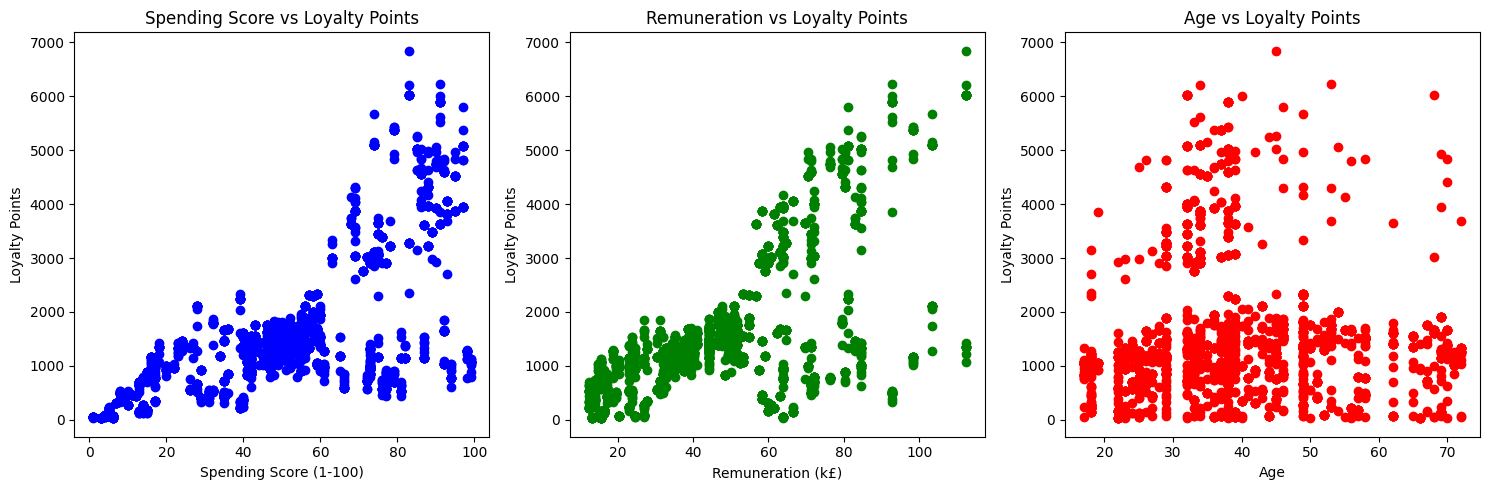

In [13]:
# Set up a figure with 3 subplots
plt.figure(figsize=(15, 5))

# Plot 1: Remuneration vs Loyalty Points
plt.subplot(1, 3, 1)
plt.scatter(reviews_new_check['spending_score'], reviews_new_check['loyalty_points'], color='blue')
plt.title("Spending Score vs Loyalty Points")
plt.xlabel("Spending Score (1-100)")
plt.ylabel("Loyalty Points")

# Plot 2: Spending Score vs Loyalty Points
plt.subplot(1, 3, 2)
plt.scatter(reviews_new_check['remuneration'], reviews_new_check['loyalty_points'], color='green')
plt.title("Remuneration vs Loyalty Points")
plt.xlabel("Remuneration (k£)")
plt.ylabel("Loyalty Points")

# Plot 3: Age vs Loyalty Points
plt.subplot(1, 3, 3)
plt.scatter(reviews_new_check['age'], reviews_new_check['loyalty_points'], color='red')
plt.title("Age vs Loyalty Points")
plt.xlabel("Age")
plt.ylabel("Loyalty Points")

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

## 5. Linear regression

### 5a) spending vs loyalty

In [14]:
# Define independent variable.
x = reviews_new_check['spending_score'].values.reshape(-1, 1)

# Define dependent variable.
y = reviews_new_check['loyalty_points'].values.reshape(-1, 1) 

# Create model and print summary of metrics.
# Specify the model.
f = 'y ~ x'
test = ols(f, data = reviews_new_check).fit()

# Print the regression table.
test.summary() 

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     1648.
Date:                Sun, 01 Dec 2024   Prob (F-statistic):          2.92e-263
Time:                        17:18:28   Log-Likelihood:                -16550.
No. Observations:                2000   AIC:                         3.310e+04
Df Residuals:                    1998   BIC:                         3.312e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -75.0527     45.931     -1.634      0.102    -165.129      15.024
x             33.0617      0.814     40.595      0.000      31.464      34.659
==============================================================================
Omnibus:                      126.554   Durbin-Watson:                   1.191
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              260.528
Skew:                           0.422   Prob(JB):                     2.67e-57
Kurtosis:                       4.554   Cond. No.                         122.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [15]:
# Extract the estimated parameters.
print("Parameters: ", test.params)  

# Extract the standard errors.
print("Standard errors: ", test.bse)  

# Extract the predicted values.
print("Predicted values: ", test.predict()) 

Parameters:  Intercept   -75.052663
x            33.061693
dtype: float64
Standard errors:  Intercept    45.930554
x             0.814419
dtype: float64
Predicted values:  [1214.35337415 2602.94449102  123.31749662 ... 2933.56142361  453.93442921
  189.44088314]


In [16]:
# Set the X coefficient and the constant to generate the regression table.
y_pred = (-75.052663) + 33.061693 * x

# View the output.
y_pred

array([[1214.353364],
       [2602.94447 ],
       [ 123.317495],
       ...,
       [2933.5614  ],
       [ 453.934425],
       [ 189.440881]])

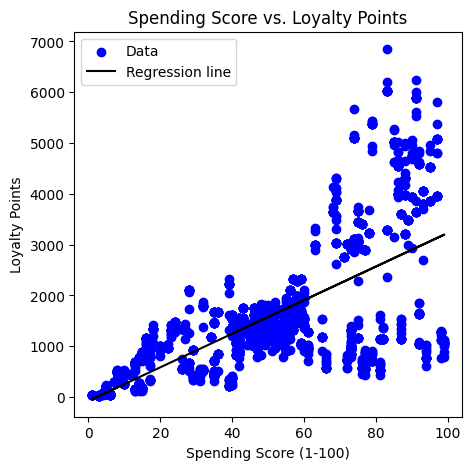

In [17]:
# Plot the graph with a regression line.
plt.figure(figsize=(5, 5))
plt.scatter(x, y, color='blue', label='Data')

# Plot the regression line (in black).
plt.plot(x, y_pred, color='black', label='Regression line')

# Set the title and legends for the graph.  
plt.title("Spending Score vs. Loyalty Points")
plt.xlabel("Spending Score (1-100)")
plt.ylabel("Loyalty Points") 

# View the plot.
plt.legend(loc='upper left')
plt.show()

### 5b) renumeration vs loyalty

In [18]:
# Define independent variable.
x = reviews_new_check['remuneration'].values.reshape(-1, 1)

# Define dependent variable.
y = reviews_new_check['loyalty_points'].values.reshape(-1, 1) 

# Create model and print summary of metrics.
# Specify the model.
f = 'y ~ x'
test = ols(f, data = reviews_new_check).fit()

# Print the regression table.
test.summary() 

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     1222.
Date:                Sun, 01 Dec 2024   Prob (F-statistic):          2.43e-209
Time:                        17:19:49   Log-Likelihood:                -16674.
No. Observations:                2000   AIC:                         3.335e+04
Df Residuals:                    1998   BIC:                         3.336e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -65.6865     52.171     -1.259      0.208    -168.001      36.628
x             34.1878      0.978     34.960      0.000      32.270      36.106
==============================================================================
Omnibus:                       21.285   Durbin-Watson:                   3.622
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               31.715
Skew:                           0.089   Prob(JB):                     1.30e-07
Kurtosis:                       3.590   Cond. No.                         123.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [19]:
# Extract the estimated parameters.
print("Parameters: ", test.params)  

# Extract the standard errors.
print("Standard errors: ", test.bse)  

# Extract the predicted values.
print("Predicted values: ", test.predict()) 

Parameters:  Intercept   -65.686513
x            34.187825
dtype: float64
Standard errors:  Intercept    52.170717
x             0.977925
dtype: float64
Predicted values:  [ 354.82374068  354.82374068  382.85775758 ... 3102.15739671 3298.39551499
 3102.15739671]


In [20]:
# Set the X coefficient and the constant to generate the regression table.
y_pred = (-65.686513) + 34.187825 * x

# View the output.
y_pred

array([[ 354.8237345],
       [ 354.8237345],
       [ 382.857751 ],
       ...,
       [3102.1573515],
       [3298.395467 ],
       [3102.1573515]])

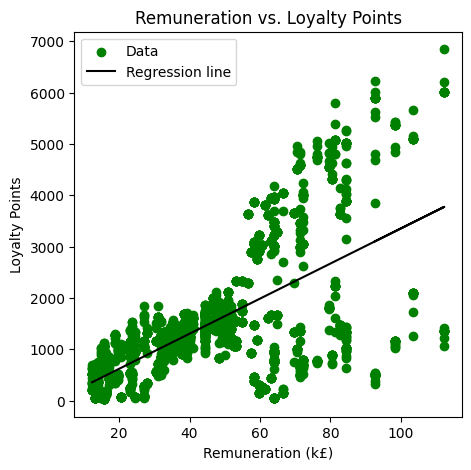

In [21]:
# Plot the graph with a regression line.
plt.figure(figsize=(5, 5))
plt.scatter(x, y, color='green', label='Data')

# Plot the regression line (in black).
plt.plot(x, y_pred, color='black', label='Regression line')

# Set the title and legends for the graph.  
plt.title("Remuneration vs. Loyalty Points")
plt.xlabel("Remuneration (k£)")
plt.ylabel("Loyalty Points") 

# View the plot.
plt.legend(loc='upper left')
plt.show()

### 5c) age vs loyalty

In [22]:
# Define independent variable.
x = reviews_new_check[['age']]

# Define dependent variable.
y = reviews_new_check['loyalty_points']

# Create model and print summary of metrics.
import statsmodels.formula.api as smf
formula = 'loyalty_points ~ age'

# Fit the model using the formula API
model_spending = smf.ols(formula, data=reviews_new_check).fit()

# Print the summary of the regression model
model_spending.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         loyalty_points   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.606
Date:                Sun, 01 Dec 2024   Prob (F-statistic):             0.0577
Time:                        17:19:54   Log-Likelihood:                -17150.
No. Observations:                2000   AIC:                         3.430e+04
Df Residuals:                    1998   BIC:                         3.431e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1736.5177     88.249     19.678      0.000    1563.449    1909.587
age           -4.0128      2.113     -1.899      0.058      -8.157       0.131
==============================================================================
Omnibus:                      481.477   Durbin-Watson:                   2.277
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              937.734
Skew:                           1.449   Prob(JB):                    2.36e-204
Kurtosis:                       4.688   Cond. No.                         129.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [23]:
# Extract the estimated parameters.
print("Parameters: ", test.params)  

# Extract the standard errors.
print("Standard errors: ", test.bse)  

# Extract the predicted values.
print("Predicted values: ", test.predict()) 

Parameters:  Intercept   -65.686513
x            34.187825
dtype: float64
Standard errors:  Intercept    52.170717
x             0.977925
dtype: float64
Predicted values:  [ 354.82374068  354.82374068  382.85775758 ... 3102.15739671 3298.39551499
 3102.15739671]


In [24]:
# Set the X coefficient and the constant to generate the regression table.
y_pred = (1736.517739) + (-4.012805) * x

# View the output.
y_pred

,age
0,1664.287249
1,1644.223224
2,1648.236029
3,1636.197614
4,1604.095174
...,...
1995,1588.043954
1996,1563.967124
1997,1600.082369
1998,1600.082369


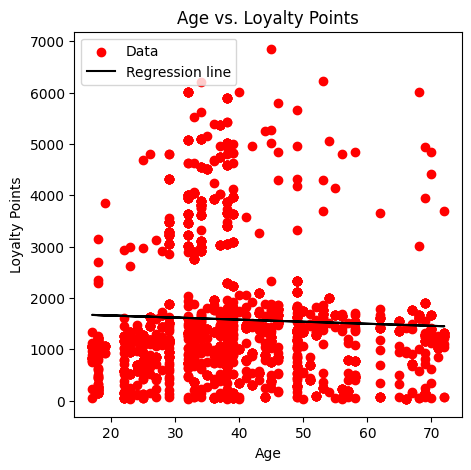

In [25]:
# Plot graph with regression line.
# Plot the graph with a regression line.
plt.figure(figsize=(5, 5))
plt.scatter(x, y, color='red', label='Data')

# Plot the regression line (in black).
plt.plot(x, y_pred, color='black', label='Regression line')

# Set the title and legends for the graph.  
plt.title("Age vs. Loyalty Points")
plt.xlabel("Age")
plt.ylabel("Loyalty Points") 

# View the plot.
plt.legend(loc='upper left')
plt.show()

## 6. Observations and insights

In this part of the research, the loyalty point values are related to the spending score, the remuneration, and the age of the customers. Here, some pbservations about the linear regression between these metrics and the loyalty points.

### Spending score vs. loyalty points plot
Customers are ranked according to their spending score, from 1 (worst spendors) to 100 (best spendors). The higher the spending score, the higher the loyalty points. Besides that, the spread of the loyalty points increaes with increasing the remuneration.  
A linear relationship between the two quantities is present (black line), although the R<sup>2</sup> value of 0.380 suggests a linear relationship not very strong.

### Renumeration vs. loyalty points plot
In this case, the higher the remuneration (customer income), the higher the loyalty points. Besides that, the spread of the loyalty points with incresing the remuneration increases as well.  
There is however a linear relationship between the two quantities (black line), even if the R<sup>2</sup> value of 0.452 suggests a linear relationship not very strong, but stronger than in hte case of the spending score vs. loyalty points.

### Age vs. loyalty points plot
In the case of searching for a linera relationship between age and loyalty points, it can be noticed how the data are evely spread across the plot. This means that the age is not an important factor, when it's related to the loyalty points. This fact is proven by a non-existing linear relation (black line), supported by a very small R<sup>2</sup> value of 0.002.







# Week 2 assignment: Exploring the structure using decision trees.

The team wants you to use decision trees to attempt to better understand the structure found in the data. You need to grow and prune a decision tree regressor and then visualise and interpret the output.
Make sure to comment on the potential usefulness in decision-making processes and your observations regarding the model.

## Instructions
1. Prepare the data for creating your decision tree. 
    1. Import the CSV file you have prepared in Week 1.
    2. Create a new DataFrame with the appropriate columns.
        1. Specify that loyalty points is the target variable (Y) and should be excluded from your input data.
        2. Specify X for the independent variables and y as the dependent variable. Therefore, df\[cols\] will be the independent variables and the column containing loyalty points the dependent variable.
        3. Explore the new DataFrame. 
2. Split the data set into a train and test sets for both X and y at a 70:30 ratio. As previously, random_state=42.
3. Create a decision tree regressor to explore the impact of other features on the loyalty points.
    1. Import the DecisionTreeRegressor class from the sklearn.tree library. 
    2. Create a variable (e.g. regressor) to store the DecisionTreeRegressor() class. (As previously, random_state=42.).
    3. Fit the regressor object to the data set with the fit() function.
    4. Remember to prune your tree using basic pruning strategies and compare the performance before and after applying the pruning strategy.
    5. Plot the final decision tree.
4. Fit a final model and interpret the output.
    1. Justify your selection of pruning strategy implemented and interpret the output.
    2. Evaluate the usefulness of the obtained result and interpret the tree and how it could be used to inform business decisions in the organisation.
5. Summarise (150–200 words) the most important business insights, anything you would like to explore further, and suggested future actions.
 
Back up your work to a safe location. This will allow you to revert to a previous state in the case of making a mistake in the code or deleting a section by mistake. (A simple way of doing this is to save or email a compressed version to yourself at frequent intervals.)


## 1. Load and prepare the data

In [30]:
# Import all the necessary packages
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree 
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay #, plot_confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

import statsmodels.api as sm
import warnings
import matplotlib.pyplot as plt
import math

# Settings for the notebook.
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = [15, 10]

In [31]:
# Create your new DataFrame.
df = pd.read_csv(r'C:\Users\bocco\OneDrive\Documents\Education\20240708-20250208 - LSE - Data Analytics Career Accelerator\Course 3'
                   r'\Assigment\LSE_DA301_assignment_files_new\reviews_new.csv')

# Check the shape of the imported DataFrame
print("Shape of the imported DataFrame:", df.shape)

# View DataFrame info.
print(df.info())

Shape of the imported DataFrame: (2000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          2000 non-null   object 
 1   age             2000 non-null   int64  
 2   remuneration    2000 non-null   float64
 3   spending_score  2000 non-null   int64  
 4   loyalty_points  2000 non-null   int64  
 5   education       2000 non-null   object 
 6   product         2000 non-null   int64  
 7   review          2000 non-null   object 
 8   summary         2000 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 140.8+ KB
None


In [32]:
# View DataFrame head.
df.head()

,gender,age,remuneration,spending_score,loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


In [33]:
# Map the gender
gender_counts = df['gender'].value_counts()

# Map these counts to the Education column
df['gender_encoded'] = df['gender'].map({'Male': 0, 'Female': 1})
print(gender_counts)
df

gender
Female    1120
Male       880
Name: count, dtype: int64


,gender,age,remuneration,spending_score,loyalty_points,education,product,review,summary,gender_encoded
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...,0
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...,0
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless",1
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars,1
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap,1
...,...,...,...,...,...,...,...,...,...,...
1995,Female,37,84.46,69,4031,PhD,977,The perfect word game for mixed ages (with Mom...,The perfect word game for mixed ages (with Mom,1
1996,Female,43,92.66,8,539,PhD,979,Great game. Did not think I would like it whe...,Super fun,1
1997,Male,34,92.66,91,5614,graduate,1012,Great game for all.........\nKeeps the mind ni...,Great Game,0
1998,Male,34,98.40,16,1048,PhD,1031,fun game!,Four Stars,0


In [34]:
# Calculate frequency of each education level
education_counts = df['education'].value_counts()

# Map these counts to the Education column
df['education_encoded'] = df['education'].map(education_counts)
print(education_counts)
df

education
graduate        900
PhD             460
postgraduate    400
diploma         190
Basic            50
Name: count, dtype: int64


,gender,age,remuneration,spending_score,loyalty_points,education,product,review,summary,gender_encoded,education_encoded
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...,0,900
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...,0,900
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless",1,900
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars,1,900
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap,1,900
...,...,...,...,...,...,...,...,...,...,...,...
1995,Female,37,84.46,69,4031,PhD,977,The perfect word game for mixed ages (with Mom...,The perfect word game for mixed ages (with Mom,1,460
1996,Female,43,92.66,8,539,PhD,979,Great game. Did not think I would like it whe...,Super fun,1,460
1997,Male,34,92.66,91,5614,graduate,1012,Great game for all.........\nKeeps the mind ni...,Great Game,0,900
1998,Male,34,98.40,16,1048,PhD,1031,fun game!,Four Stars,0,460


In [35]:
# Specify that loyalty points is the target variable (Y) and should be excluded from your input data.
nec_cols = ['gender_encoded', 'age', 'remuneration', 'spending_score', 'education_encoded', 'product']

# Specify Y.
y = df.loc[:, df.columns == 'loyalty_points']  
# Specify X.
X = df[nec_cols]  

In [36]:
# Review X and Y.
print(X)
print(y)

      gender_encoded  age  remuneration  spending_score  education_encoded  \
0                  0   18         12.30              39                900   
1                  0   23         12.30              81                900   
2                  1   22         13.12               6                900   
3                  1   25         13.12              77                900   
4                  1   33         13.94              40                900   
...              ...  ...           ...             ...                ...   
1995               1   37         84.46              69                460   
1996               1   43         92.66               8                460   
1997               0   34         92.66              91                900   
1998               0   34         98.40              16                460   
1999               0   32         92.66               8                460   

      product  
0         453  
1         466  
2         254  

## 2. Create train and test data sets.

In [37]:
# Split the data into test and train data.
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=42)

# Check the size of the 4 subsets
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1400, 6), (1400, 1), (600, 6), (600, 1))

## 3. Create Decision tree regressor

In [38]:
# Create your decision tree regressor.
regressor = DecisionTreeRegressor(random_state=42)

# Fit the regressor object to the data set.
regressor.fit(X_train,y_train)  

DecisionTreeRegressor(random_state=42)

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

In [47]:
# Evaluate the model.
# Predict the response for the data test.
y_predict = regressor.predict(X_test) 

# Calculate the R^2 score for the training data
train_r2 = regressor.score(X_train, y_train)
print("Training R^2 Score:", train_r2)

# Calculate the R^2 score for the testing data
test_r2 = regressor.score(X_test, y_test)
print("Testing R^2 Score:", test_r2)

print("Mean Absolute Error (MAE): ", mean_absolute_error(y_test, y_predict))
print("Mean Squared Error (MSE): ", mean_squared_error(y_test, y_predict))
print("Root Mean Squared Error (RMSE): ", math.sqrt(mean_squared_error(y_test, y_predict)))

#print("Mean Absolute Error (MAE): ", metrics.mean_absolute_error(y_test, y_predict))
#print("Mean Squared Error (RSE): ", metrics.mean_squared_error(y_test, y_predict))
# Calculate the RMSE.
#print("Root Mean Squared Error (RMSE): ", 
#     math.sqrt(metrics.mean_squared_error(y_test, y_predict)))

Training R^2 Score: 1.0
Testing R^2 Score: 0.9950294047576341
Mean Absolute Error (MAE):  33.375
Mean Squared Error (MSE):  8051.355
Root Mean Squared Error (RMSE):  89.72934302668219


In [49]:
# Prune the model.
regressor = DecisionTreeRegressor(random_state=42, 
                                  max_depth=5,            # Limit the depth of the tree
                                  min_samples_split=10,    # Minimum samples required to split a node
                                  min_impurity_decrease=0.01  # Minimum impurity decrease to make a split
)

## 4. Fit and plot final model.

Training R^2 Score: 0.9612192051375839
Testing R^2 Score: 0.9566506653144026
Mean Absolute Error (MAE):  177.11368640533988
Mean Squared Error (MSE):  70217.11999254132
Root Mean Squared Error (RMSE):  264.9851316442893


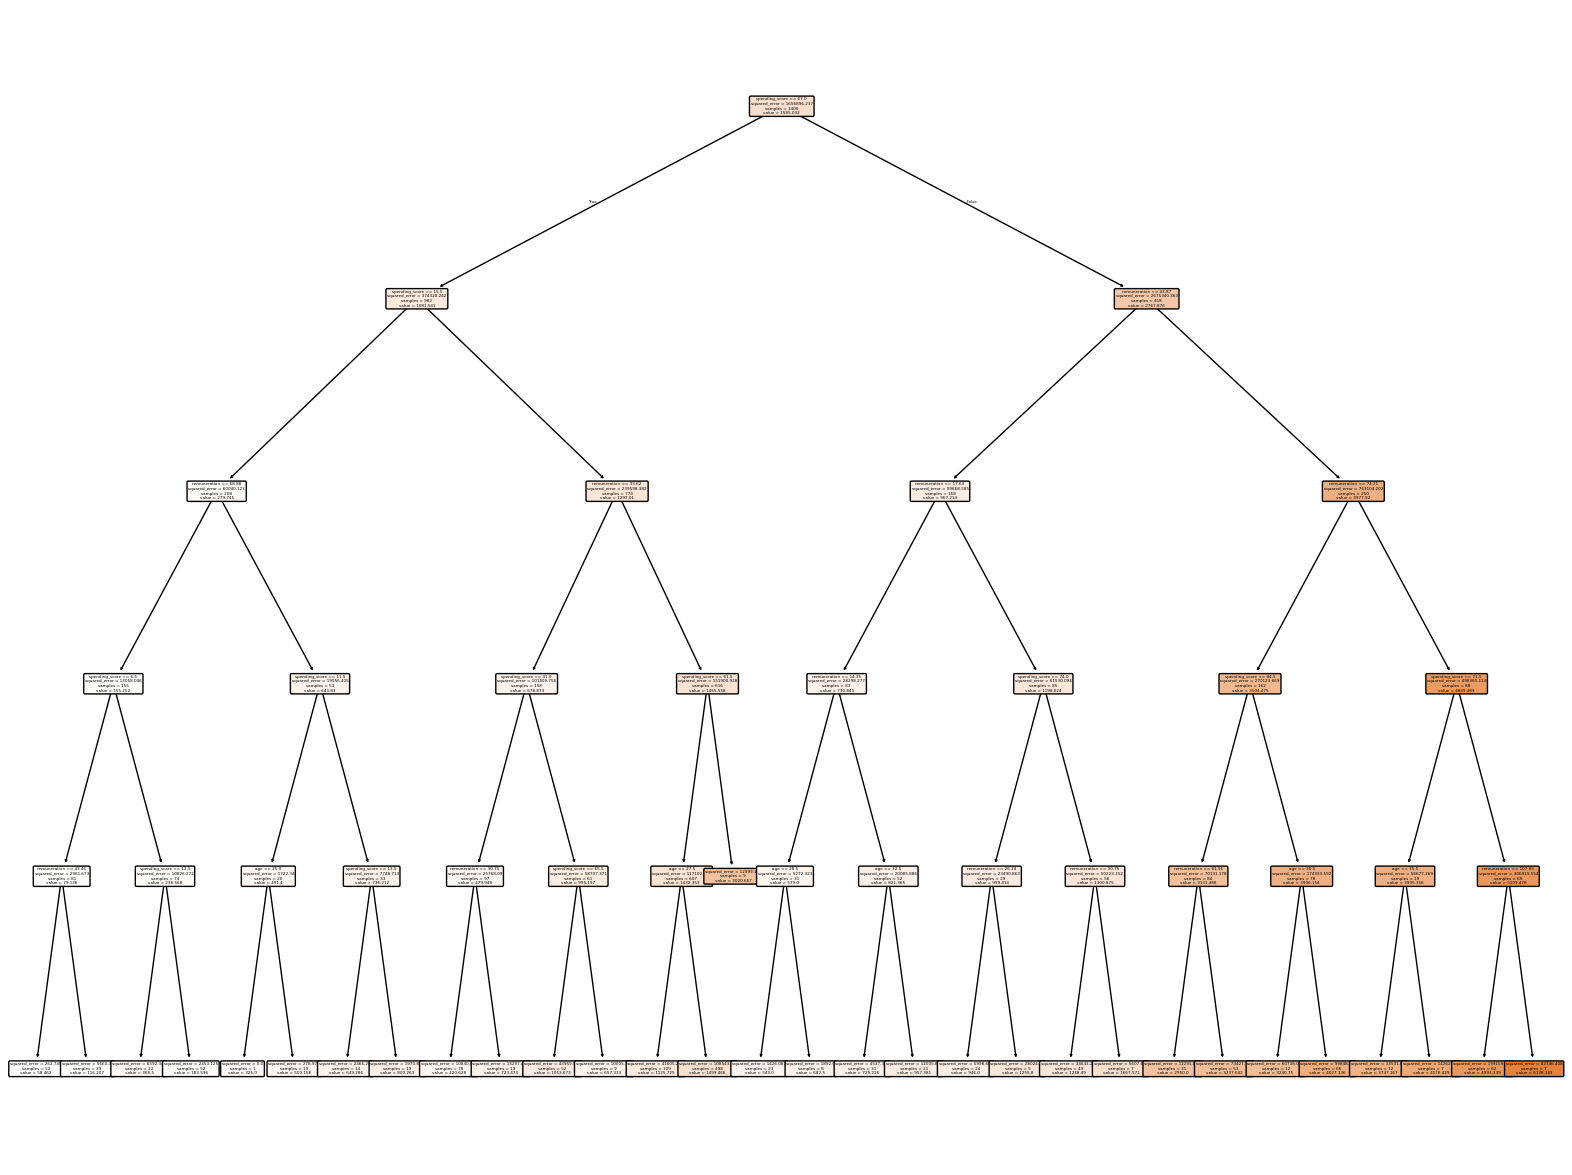

Depth = 5
Leaves = 31


In [52]:
# Fit and plot final model.

# Fit the model
regressor.fit(X_train, y_train)
# Predict the response for the data test.
y_predict = regressor.predict(X_test) 

# Calculate the R^2 score for the training data
train_r2 = regressor.score(X_train, y_train)
print("Training R^2 Score:", train_r2)

# Calculate the R^2 score for the testing data
test_r2 = regressor.score(X_test, y_test)
print("Testing R^2 Score:", test_r2)

# Specify to print the MAE and MSE (to evaluate the accuracy of the new model).
print("Mean Absolute Error (MAE): ", mean_absolute_error(y_test, y_predict))
print("Mean Squared Error (MSE): ", mean_squared_error(y_test, y_predict))
print("Root Mean Squared Error (RMSE): ", math.sqrt(mean_squared_error(y_test, y_predict)))
#print("Mean Absolute Error (MAE): ", metrics.mean_absolute_error(y_test, y_predict))
#print("Mean Squared Error (MSE): ", metrics.mean_squared_error(y_test, y_predict))
# Calculate the RMSE.
#print("Root Mean Squared Error (RMSE): ", 
#     math.sqrt(metrics.mean_squared_error(y_test, y_predict))) 

plt.figure(figsize=(20, 15))  # Increase the figure size
plot_tree(regressor, 
          feature_names=X.columns,  # Provide feature names for readability
          filled=True,              # Color nodes based on purity
          rounded=True,             # Rounded corners
          impurity=True,            # Shows the MSE at each node
          fontsize=3                # Adjust font size for readability
)

# Save the decision tree plot as a PNG file
plt.savefig("Corrado_Locati_Course_3_Assigment_Week_2_decision_tree.png", format='png', dpi=300)

# Show the plot
plt.show()

print("Depth =", regressor.get_depth())
print('Leaves =', regressor.get_n_leaves())

## 5. Discuss: Insights and observations

### Discussion of the results from the pruned decision tree

The most important variables related to the loyalty points are spending score, remuneration and age. Gender, education and kind of purchased products are not relevant, accoding to this particular pruned decision tree.

As expected, the highest number of loyalty point is reached by people with high spending score and high remuneration (income). In this particular case, the highest number of loyalty points, on average (6138.143), is reached with a spending score higher than 71.5 and a remuneration higher than 107.830 GBP. The squared error is pretty high, though, 83476.408. 

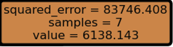

However, the largest group of customers (498) reaches an average of 1499.466 loyalty points. Such group is older than 27.5 years, with a spending score of 61.5 and a remuneration higher 33620 GBP. Also in this case, the squared error is pretty high, i.e., 108543.61.

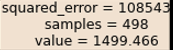

Such high squared errors suggest that a further splitting could be beneficial for a deeper understanding of the relation between the variables determining the loyalty points and the loyalty points themselves. 

In any case, Turtle Games could benefit from marketing campaigns towards wealth customers with high spending score, perhaps by introducing premium games (rare and high-end game editions), or with exclusive promotions. On the other hand, Turtle Games should also focus part of their marketing campaigns towards young and not-so-wealth customers, with a spending score approx. half way between 0 and 50, since they are the biggest group. 

If Turtle Games has nowadays campaigns or promotions towards a specific gender, or education level, or targetting specific products, they should drop them, since it appears from the analysis that they are not important in cathegorizing groups within certain amounts of loyalty points. 

# 

# Week 3 assignment: Clustering with *k*-means using Python

The marketing department also wants to better understand the usefulness of renumeration and spending scores but do not know where to begin. You are tasked to identify groups within the customer base that can be used to target specific market segments. Use *k*-means clustering to identify the optimal number of clusters and then apply and plot the data using the created segments.

## Instructions
1. Prepare the data for clustering. 
    1. Import the CSV file you have prepared in Week 1.
    2. Create a new DataFrame (e.g. `df3`) containing the `renumeration` and `spending_score` columns.
    3. Explore the new DataFrame. 
2. Plot the renumeration versus spending score.
    1. Create a scatterplot.
    2. Create a pairplot.
3. Use the Silhouette and Elbow methods to determine the optimal number of clusters for *k*-means clustering.
    1. Plot both methods and explain how you determine the number of clusters to use.
    2. Add titles and legends to the plot.
4. Evaluate the usefulness of at least three values for *k* based on insights from the Elbow and Silhoutte methods.
    1. Plot the predicted *k*-means.
    2. Explain which value might give you the best clustering.
5. Fit a final model using your selected value for *k*.
    1. Justify your selection and comment on the respective cluster sizes of your final solution.
    2. Check the number of observations per predicted class.
6. Plot the clusters and interpret the model.

## 1. Load and explore the data

In [53]:
# Import necessary libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist

import warnings
warnings.filterwarnings('ignore')

In [54]:
# Load the CSV file(s) as df2.
# Create your new DataFrame.
df2 = pd.read_csv(r'C:\Users\bocco\OneDrive\Documents\Education\20240708-20250208 - LSE - Data Analytics Career Accelerator\Course 3'
                   r'\Assigment\LSE_DA301_assignment_files_new\reviews_new.csv')

# Check the shape of the imported DataFrame
print("Shape of the imported DataFrame:", df2.shape)

# View DataFrame info.
print(df2.info())

Shape of the imported DataFrame: (2000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          2000 non-null   object 
 1   age             2000 non-null   int64  
 2   remuneration    2000 non-null   float64
 3   spending_score  2000 non-null   int64  
 4   loyalty_points  2000 non-null   int64  
 5   education       2000 non-null   object 
 6   product         2000 non-null   int64  
 7   review          2000 non-null   object 
 8   summary         2000 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 140.8+ KB
None


In [56]:
# Drop unnecessary columns.
df3=df2[['remuneration', 'spending_score', 'loyalty_points']]

# View DataFrame.
df3

,remuneration,spending_score,loyalty_points
0,12.30,39,210
1,12.30,81,524
2,13.12,6,40
3,13.12,77,562
4,13.94,40,366
...,...,...,...
1995,84.46,69,4031
1996,92.66,8,539
1997,92.66,91,5614
1998,98.40,16,1048


In [57]:
# Explore the data.
df3.value_counts()

remuneration  spending_score  loyalty_points
32.80         42              904               10
22.96         82              1150              10
44.28         42              1379               8
71.34         13              648                8
              10              499                8
                                                ..
44.28         46              1315               1
              44              1445               1
                              1024               1
12.30         39              252                1
112.34        83              6847               1
Name: count, Length: 710, dtype: int64

In [58]:
# Descriptive statistics.
df3.describe()

,remuneration,spending_score,loyalty_points
count,2000.000000,2000.000000,2000.000000
mean,48.079060,50.000000,1578.032000
std,23.123984,26.094702,1283.239705
min,12.300000,1.000000,25.000000
25%,30.340000,32.000000,772.000000
50%,47.150000,50.000000,1276.000000
75%,63.960000,73.000000,1751.250000
max,112.340000,99.000000,6847.000000


## 2. Plot

<Axes: xlabel='remuneration', ylabel='spending_score'>

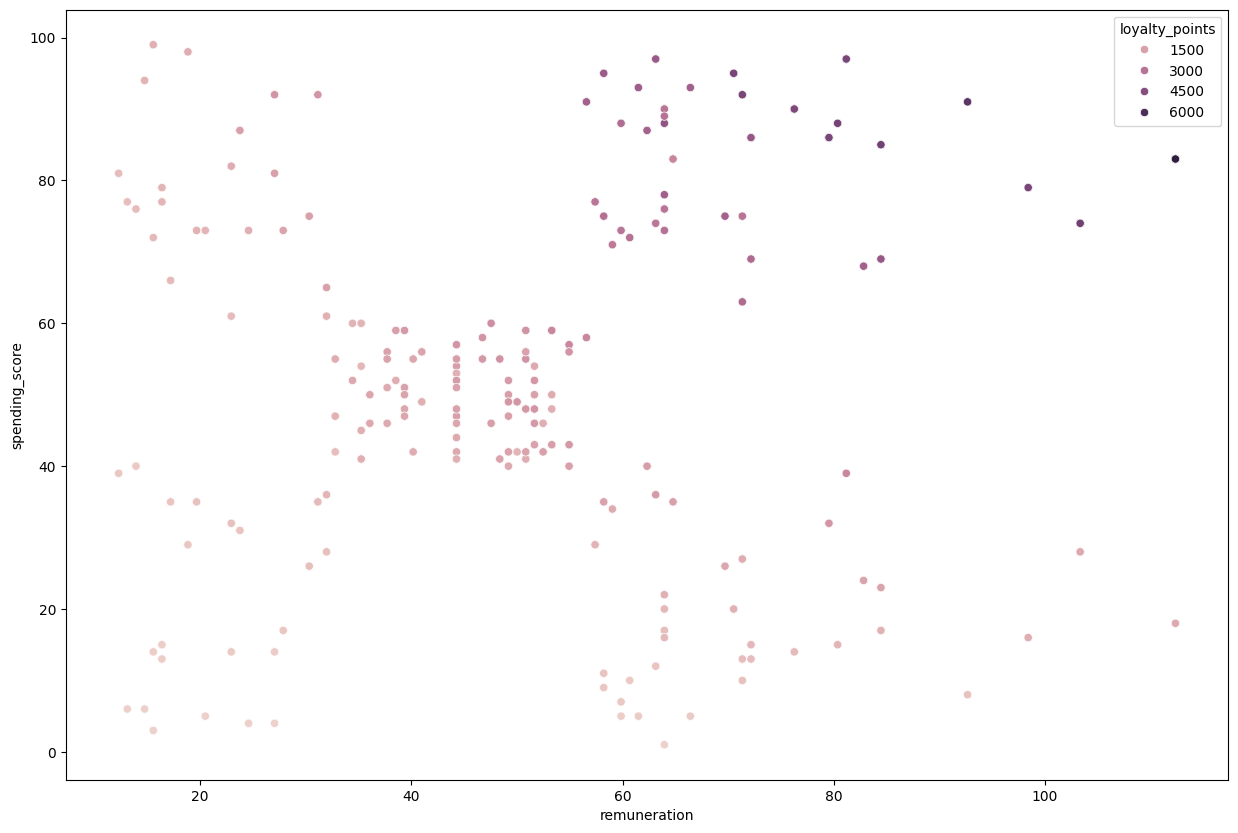

In [59]:
# Create a scatterplot with Seaborn.
# Import Seaborn and Matplotlib.
from matplotlib import pyplot as plt
import seaborn as sns

# Create a scatterplot with Seaborn.
sns.scatterplot(x='remuneration',
                y='spending_score',
                hue='loyalty_points',
                data=df3,
                )

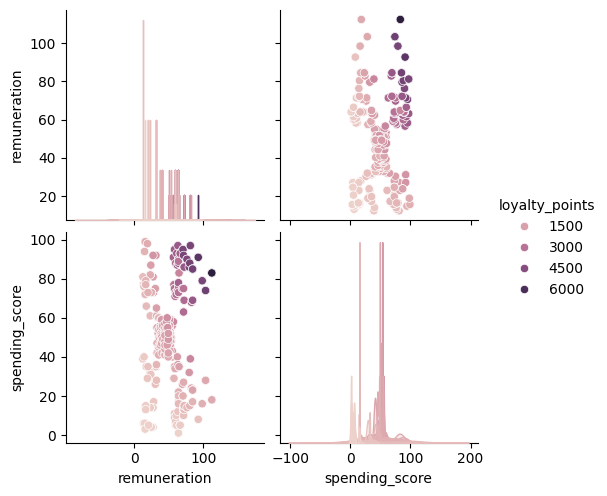

In [60]:
# Create a pairplot with Seaborn.
x = df3[['remuneration', 'spending_score']]

sns.pairplot(df3,
             vars=x,
             hue='loyalty_points',
             diag_kind= 'kde'
            )

## 3. Elbow and silhoutte methods

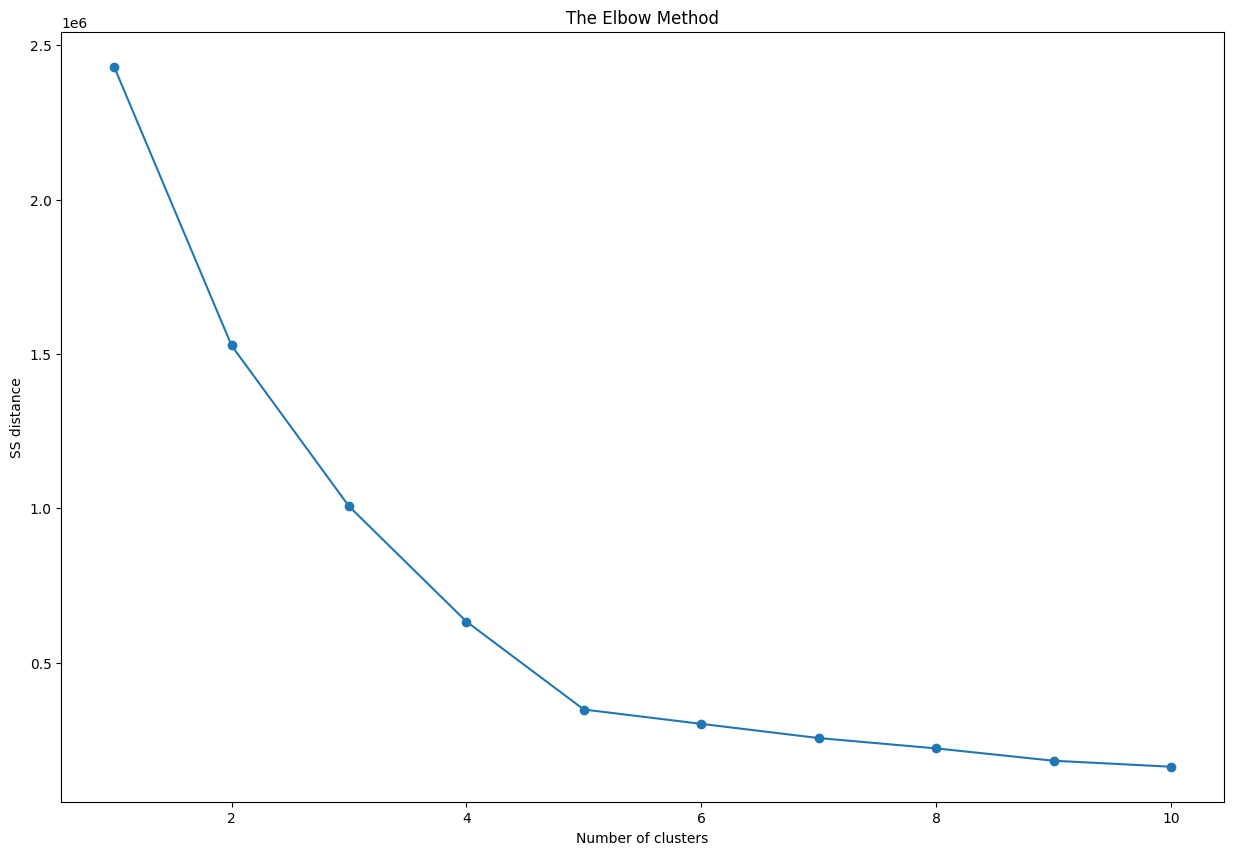

In [61]:
# Determine the number of clusters: Elbow method.
# Import the KMeans class.
from sklearn.cluster import KMeans 

# Elbow chart for us to decide on the number of optimal clusters.
ss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i,
                    init='k-means++',
                    max_iter=300,
                    n_init=10,
                    random_state=0)
    kmeans.fit(x)
    ss.append(kmeans.inertia_)

# Plot the elbow method.
plt.plot(range(1, 11),
         ss,
         marker='o')

# Insert labels and title.
plt.title("The Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("SS distance")

plt.show()

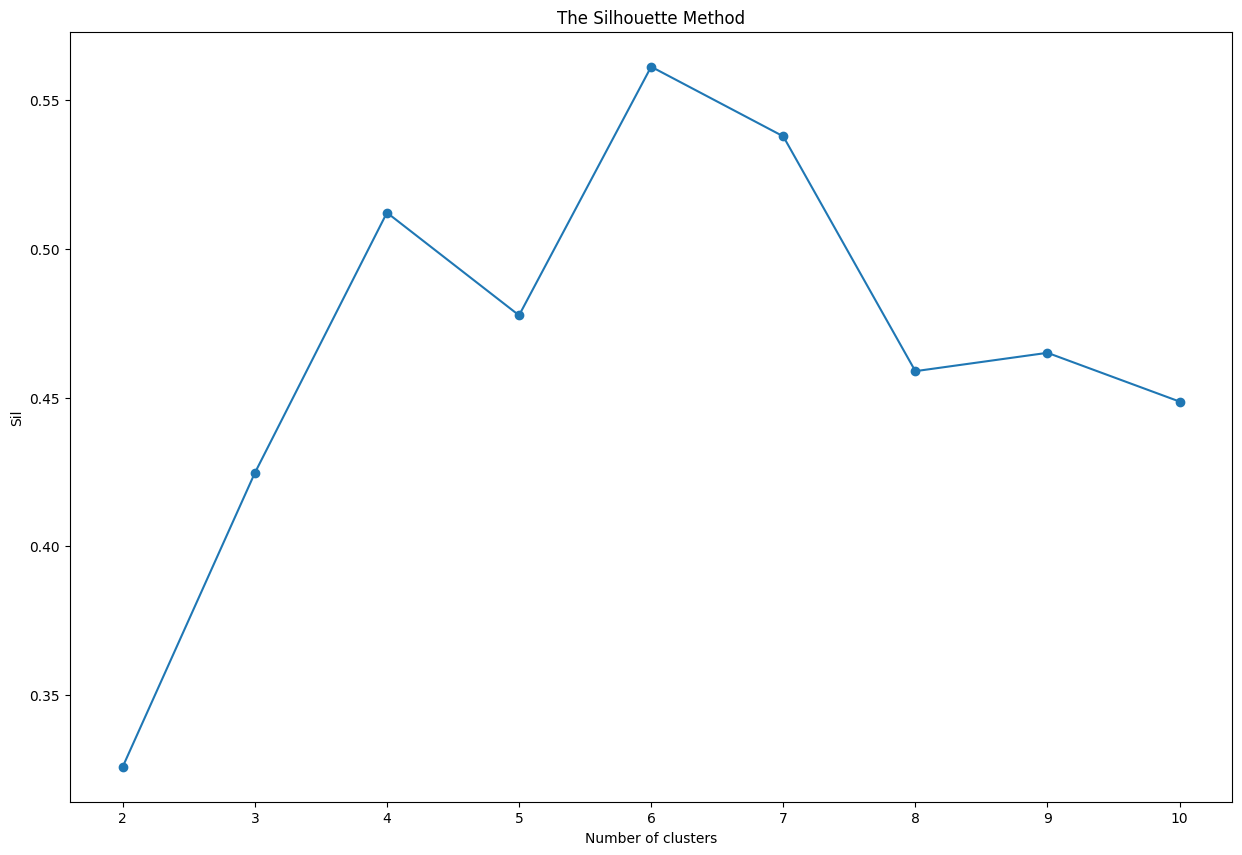

In [62]:
# Determine the number of clusters: Silhouette method.
# Import silhouette_score class from sklearn.
from sklearn.metrics import silhouette_score

# Find the range of clusters to be used using silhouette method.
sil = []
kmax = 10

for k in range(2, kmax+1):
    kmeans_s = KMeans(n_clusters=k).fit(x)
    labels = kmeans_s.labels_
    sil.append(silhouette_score(x,
                                labels,
                                metric='euclidean'))

# Plot the silhouette method.
plt.plot(range(2, kmax+1),
         sil,
         marker='o')

# Insert labels and title.
plt.title("The Silhouette Method")
plt.xlabel("Number of clusters")
plt.ylabel("Sil")

plt.show()

## 4. Evaluate k-means model at different values of *k*

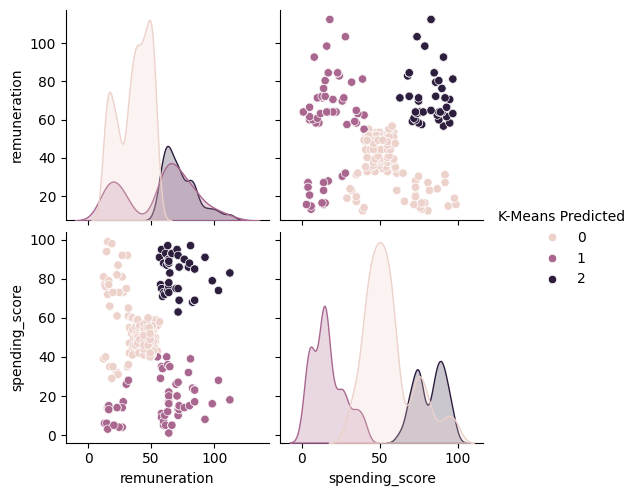

In [63]:
# Use three clusters.
kmeans = KMeans(n_clusters = 3, 
                max_iter = 15000,
                init='k-means++',
                random_state=0).fit(x)

clusters = kmeans.labels_

x['K-Means Predicted'] = clusters

# Plot the predicted.
sns.pairplot(x,
             hue='K-Means Predicted',
             diag_kind= 'kde')

In [64]:
# Check the number of observations per predicted class.
x['K-Means Predicted'].value_counts()

K-Means Predicted
0    1114
1     530
2     356
Name: count, dtype: int64

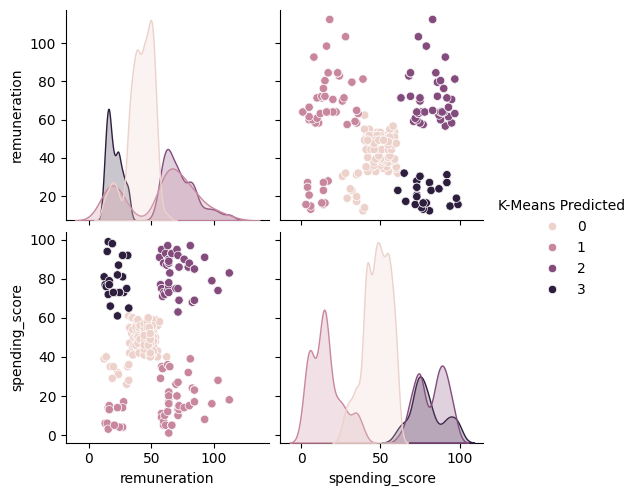

In [65]:
# Use four clusters.
kmeans = KMeans(n_clusters = 4, 
                max_iter = 15000,
                init='k-means++',
                random_state=0).fit(x)

clusters = kmeans.labels_

x['K-Means Predicted'] = clusters

# Plot the predicted.
sns.pairplot(x,
             hue='K-Means Predicted',
             diag_kind= 'kde')

In [121]:
# Check the number of observations per predicted class.
x['K-Means Predicted'].value_counts()

K-Means Predicted
0    1013
3     356
2     351
1     280
Name: count, dtype: int64

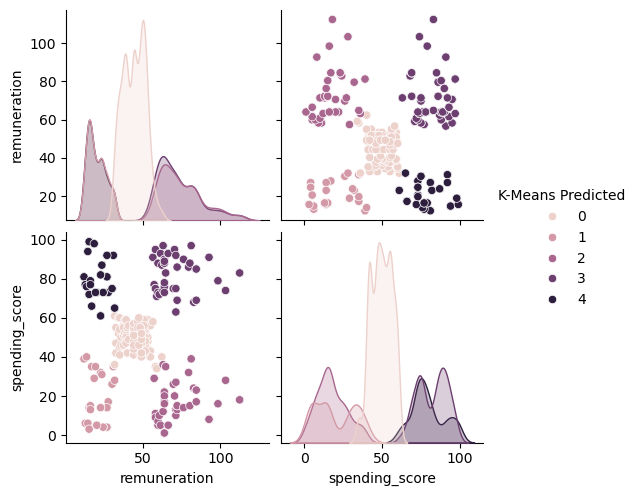

In [124]:
# Use five clusters.
kmeans = KMeans(n_clusters = 5, 
                max_iter = 15000,
                init='k-means++',
                random_state=0).fit(x)

clusters = kmeans.labels_

x['K-Means Predicted'] = clusters

# Plot the predicted.
sns.pairplot(x,
             hue='K-Means Predicted',
             diag_kind= 'kde')

In [66]:
# Check the number of observations per predicted class.
x['K-Means Predicted'].value_counts()

K-Means Predicted
0    877
1    498
2    356
3    269
Name: count, dtype: int64

In [67]:
# View the K-Means predicted.
print(x.head())

   remuneration  spending_score  K-Means Predicted
0         12.30              39                  0
1         12.30              81                  3
2         13.12               6                  1
3         13.12              77                  3
4         13.94              40                  0


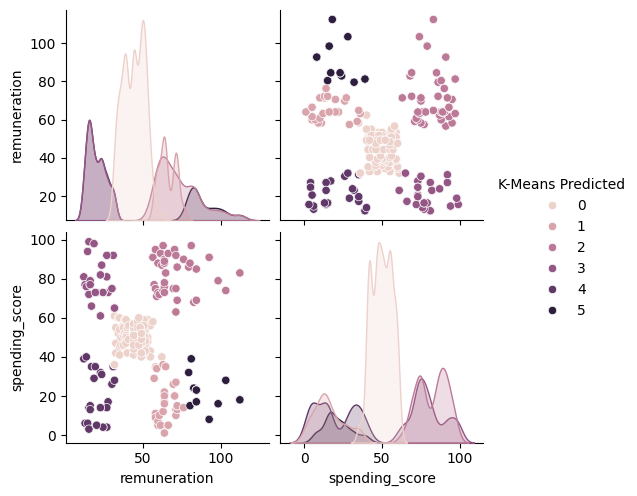

In [68]:
# Use six clusters.
kmeans = KMeans(n_clusters = 6, 
                max_iter = 15000,
                init='k-means++',
                random_state=0).fit(x)

clusters = kmeans.labels_

x['K-Means Predicted'] = clusters

# Plot the predicted.
sns.pairplot(x,
             hue='K-Means Predicted',
             diag_kind= 'kde')

In [69]:
# Check the number of observations per predicted class.
x['K-Means Predicted'].value_counts()

K-Means Predicted
0    767
2    356
4    271
3    269
1    214
5    123
Name: count, dtype: int64

## 5. Fit final model and justify your choice

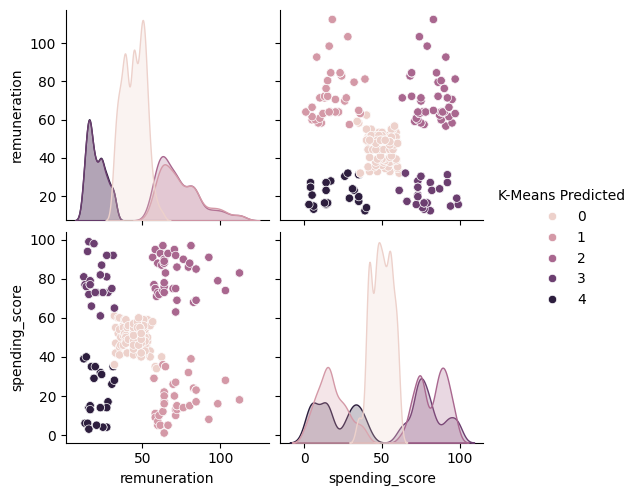

In [70]:
# Apply the final model, with five clusters.
kmeans = KMeans(n_clusters = 5, 
                max_iter = 15000,
                init='k-means++',
                random_state=0).fit(x)

clusters = kmeans.labels_

x['K-Means Predicted'] = clusters

# Plot the predicted.
sns.pairplot(x,
             hue='K-Means Predicted',
             diag_kind= 'kde')

In [72]:
# Check the number of observations per predicted class.
x['K-Means Predicted'].value_counts()

K-Means Predicted
0    774
2    356
1    330
4    271
3    269
Name: count, dtype: int64

## 6. Plot and interpret the clusters

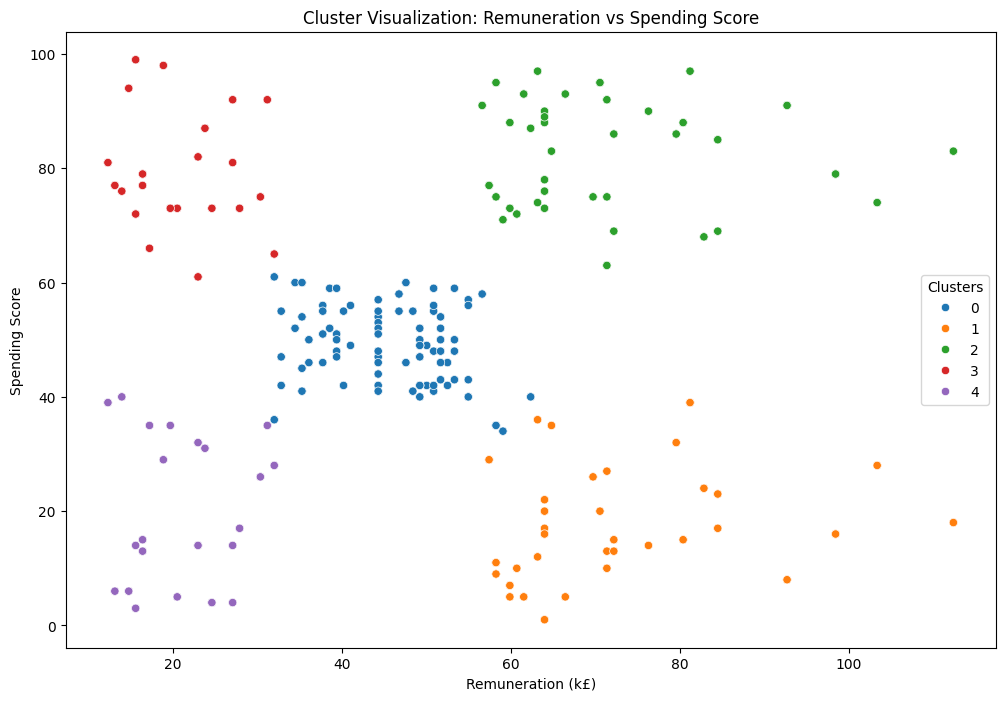

      remuneration  spending_score  K-Means Predicted
0            12.30              39                  4
1            12.30              81                  3
2            13.12               6                  4
3            13.12              77                  3
4            13.94              40                  4
...            ...             ...                ...
1995         84.46              69                  2
1996         92.66               8                  1
1997         92.66              91                  2
1998         98.40              16                  1
1999         92.66               8                  1

[2000 rows x 3 columns]


In [73]:
# Visualising the clusters.

import seaborn as sns
import matplotlib.pyplot as plt

# Set plot size
plt.figure(figsize=(12, 8))

# Create a scatter plot
sns.scatterplot(
    x='remuneration',              # X-axis: remuneration
    y='spending_score',            # Y-axis: spending score
    hue='K-Means Predicted',       # Color by cluster
    palette='tab10',               # Palette for distinct cluster colors
    data=x                       # DataFrame containing the data
)

# Add labels and title
plt.xlabel("Remuneration (k£)")
plt.ylabel("Spending Score")
plt.title("Cluster Visualization: Remuneration vs Spending Score")

# Show the plot
plt.legend(title="Clusters")  # Optional: Adjust legend
plt.show()
# View the DataFrame.
print(x)

In [74]:
# Visualising the clusters.
print(df3.columns)

x['K-Means Predicted'].value_counts()

Index(['remuneration', 'spending_score', 'loyalty_points'], dtype='object')


K-Means Predicted
0    774
2    356
1    330
4    271
3    269
Name: count, dtype: int64

## 7. Discuss: Insights and observations
From the analysis above, it can be concluded that the data can be grouped in five clusters. The cluster will be defined with approximated values of spending score and remuneration.

<font color="##4B6FAF"><b>0</font></b> = 0 - 40 spending score and 0 - 30 k£ remuneration  
<font color="#E08632"><b>1</font></b> = 0 - 40 spending score and remuneration > 55 k£  
<font color="#5FA339"><b>2</font></b> = 40 - 60 spending score and 30 - 60 k£ remuneration  
<font color="#B63132"><b>3</font></b> = 60 - 100 spending score and  0 - 30 k£ remuneration  
<font color="#8B60B9"><b>4</font></b> = 60 - 100 spending score and remuneration > 55 k£  

Customers with 0 - 40 spending score and 0 - 30 k£ remuneration form the biggest cluster (<font color="##4B6FAF"><b>0</font></b>).  
However, marketing campaigns should address customer with high, spendig scores and high remuneration (cluster <font color="#5FA339"><b>2</font></b>), as well doing promotions towards customers with low remuberation but high spending score (<font color="#B63132"><b>3</font></b>).  
Low-spending score customers, with low and high remuneration (clusters <font color="#E08632"><b>1</font></b> and <font color="#8B60B9"><b>4</font></b>, respectively) should be the target of specific promotions, in order to push their spending score.



# 

# Week 4 assignment: NLP using Python
Customer reviews were downloaded from the website of Turtle Games. This data will be used to steer the marketing department on how to approach future campaigns. Therefore, the marketing department asked you to identify the 15 most common words used in online product reviews. They also want to have a list of the top 20 positive and negative reviews received from the website. Therefore, you need to apply NLP on the data set.

## Instructions
1. Load and explore the data. 
    1. Sense-check the DataFrame.
    2. You only need to retain the `review` and `summary` columns.
    3. Determine if there are any missing values.
2. Prepare the data for NLP
    1. Change to lower case and join the elements in each of the columns respectively (`review` and `summary`).
    2. Replace punctuation in each of the columns respectively (`review` and `summary`).
    3. Drop duplicates in both columns (`review` and `summary`).
3. Tokenise and create wordclouds for the respective columns (separately).
    1. Create a copy of the DataFrame.
    2. Apply tokenisation on both columns.
    3. Create and plot a wordcloud image.
4. Frequency distribution and polarity.
    1. Create frequency distribution.
    2. Remove alphanumeric characters and stopwords.
    3. Create wordcloud without stopwords.
    4. Identify 15 most common words and polarity.
5. Review polarity and sentiment.
    1. Plot histograms of polarity (use 15 bins) for both columns.
    2. Review the sentiment scores for the respective columns.
6. Identify and print the top 20 positive and negative reviews and summaries respectively.
7. Include your insights and observations.

## 1. Load and explore the data

In [76]:
# Import all the necessary packages.
import pandas as pd
import numpy as np
import nltk 
import os 
import matplotlib.pyplot as plt

# nltk.download ('punkt').
# nltk.download ('stopwords').

from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.corpus import stopwords
from textblob import TextBlob
from scipy.stats import norm

# Import Counter.
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

In [79]:
# Load the data set as df3.
df3 = pd.read_csv(r'C:\Users\bocco\OneDrive\Documents\Education\20240708-20250208 - LSE - Data Analytics Career Accelerator\Course 3'
                   r'\Assigment\LSE_DA301_assignment_files_new\reviews_new.csv')

# Check the shape of the imported DataFrame
print("Shape of the imported DataFrame:", df3.shape)

# View DataFrame.
df3

Shape of the imported DataFrame: (2000, 9)


,gender,age,remuneration,spending_score,loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap
...,...,...,...,...,...,...,...,...,...
1995,Female,37,84.46,69,4031,PhD,977,The perfect word game for mixed ages (with Mom...,The perfect word game for mixed ages (with Mom
1996,Female,43,92.66,8,539,PhD,979,Great game. Did not think I would like it whe...,Super fun
1997,Male,34,92.66,91,5614,graduate,1012,Great game for all.........\nKeeps the mind ni...,Great Game
1998,Male,34,98.40,16,1048,PhD,1031,fun game!,Four Stars


In [80]:
# Explore data set.

print(df3.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          2000 non-null   object 
 1   age             2000 non-null   int64  
 2   remuneration    2000 non-null   float64
 3   spending_score  2000 non-null   int64  
 4   loyalty_points  2000 non-null   int64  
 5   education       2000 non-null   object 
 6   product         2000 non-null   int64  
 7   review          2000 non-null   object 
 8   summary         2000 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 140.8+ KB
None


In [81]:
# Keep necessary columns. Drop unnecessary columns.
df3 = df3[['review', 'summary']]


# View DataFrame.
df3

,review,summary
0,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,As my review of GF9's previous screens these w...,Money trap
...,...,...
1995,The perfect word game for mixed ages (with Mom...,The perfect word game for mixed ages (with Mom
1996,Great game. Did not think I would like it whe...,Super fun
1997,Great game for all.........\nKeeps the mind ni...,Great Game
1998,fun game!,Four Stars


In [82]:
# Determine if there are any missing values.
print(df3.isnull().sum())

review     0
summary    0
dtype: int64


## 2. Prepare the data for NLP
### 2a) Change to lower case and join the elements in each of the columns respectively (review and summary)

In [83]:
# Review: Change all to lower case and join with a space.
df3['review'] = df3['review'].apply(lambda x: " ".join(x.lower() for x in x.split()))

df3['review'].head()

0    when it comes to a dm's screen, the space on t...
1    an open letter to galeforce9*: your unpainted ...
2    nice art, nice printing. why two panels are fi...
3    amazing buy! bought it as a gift for our new d...
4    as my review of gf9's previous screens these w...
Name: review, dtype: object

In [84]:
# Summary: Change all to lower case and join with a space.
df3['summary'] = df3['summary'].apply(lambda x: " ".join(x.lower() for x in x.split()))

df3['summary'].head()

0    the fact that 50% of this space is wasted on a...
1    another worthless dungeon master's screen from...
2                      pretty, but also pretty useless
3                                           five stars
4                                           money trap
Name: summary, dtype: object

### 2b) Replace punctuation in each of the columns respectively (review and summary)

In [85]:
# Replace all the punctuations in review column.
df3['review'] = df3['review'].str.replace(r'[^\w\s]', '', regex=True)

# View output.
df3['review'].head()

0    when it comes to a dms screen the space on the...
1    an open letter to galeforce9 your unpainted mi...
2    nice art nice printing why two panels are fill...
3    amazing buy bought it as a gift for our new dm...
4    as my review of gf9s previous screens these we...
Name: review, dtype: object

In [86]:
# Replace all the puncuations in summary column.
df3['summary'] = df3['summary'].str.replace(r'[^\w\s]', '', regex=True)

# View output.
df3['summary'].head()

0    the fact that 50 of this space is wasted on ar...
1    another worthless dungeon masters screen from ...
2                       pretty but also pretty useless
3                                           five stars
4                                           money trap
Name: summary, dtype: object

### 2c) Drop duplicates in both columns

In [87]:
# Drop duplicates in both columns.
df3.duplicated().sum()
df3 = df3.drop_duplicates(subset=['review', 'summary'])
df3.reset_index(inplace=True)

# View DataFrame.
df3

,index,review,summary
0,0,when it comes to a dms screen the space on the...,the fact that 50 of this space is wasted on ar...
1,1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon masters screen from ...
2,2,nice art nice printing why two panels are fill...,pretty but also pretty useless
3,3,amazing buy bought it as a gift for our new dm...,five stars
4,4,as my review of gf9s previous screens these we...,money trap
...,...,...,...
1956,1995,the perfect word game for mixed ages with mom ...,the perfect word game for mixed ages with mom
1957,1996,great game did not think i would like it when ...,super fun
1958,1997,great game for all keeps the mind nimble,great game
1959,1998,fun game,four stars


## 3. Tokenise and create wordclouds

In [88]:
# Create new DataFrame (copy DataFrame).
df3_copy = df3.copy()

# View DataFrame.
df3_copy

,index,review,summary
0,0,when it comes to a dms screen the space on the...,the fact that 50 of this space is wasted on ar...
1,1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon masters screen from ...
2,2,nice art nice printing why two panels are fill...,pretty but also pretty useless
3,3,amazing buy bought it as a gift for our new dm...,five stars
4,4,as my review of gf9s previous screens these we...,money trap
...,...,...,...
1956,1995,the perfect word game for mixed ages with mom ...,the perfect word game for mixed ages with mom
1957,1996,great game did not think i would like it when ...,super fun
1958,1997,great game for all keeps the mind nimble,great game
1959,1998,fun game,four stars


In [89]:
# Apply tokenisation to both columns.
df3_copy['review_tokenised'] = df3_copy['review'].apply(word_tokenize)
df3_copy['summary_tokenised'] = df3_copy['summary'].apply(word_tokenize)

# View DataFrame.
df3_copy

,index,review,summary,review_tokenised,summary_tokenised
0,0,when it comes to a dms screen the space on the...,the fact that 50 of this space is wasted on ar...,"[when, it, comes, to, a, dms, screen, the, spa...","[the, fact, that, 50, of, this, space, is, was..."
1,1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon masters screen from ...,"[an, open, letter, to, galeforce9, your, unpai...","[another, worthless, dungeon, masters, screen,..."
2,2,nice art nice printing why two panels are fill...,pretty but also pretty useless,"[nice, art, nice, printing, why, two, panels, ...","[pretty, but, also, pretty, useless]"
3,3,amazing buy bought it as a gift for our new dm...,five stars,"[amazing, buy, bought, it, as, a, gift, for, o...","[five, stars]"
4,4,as my review of gf9s previous screens these we...,money trap,"[as, my, review, of, gf9s, previous, screens, ...","[money, trap]"
...,...,...,...,...,...
1956,1995,the perfect word game for mixed ages with mom ...,the perfect word game for mixed ages with mom,"[the, perfect, word, game, for, mixed, ages, w...","[the, perfect, word, game, for, mixed, ages, w..."
1957,1996,great game did not think i would like it when ...,super fun,"[great, game, did, not, think, i, would, like,...","[super, fun]"
1958,1997,great game for all keeps the mind nimble,great game,"[great, game, for, all, keeps, the, mind, nimble]","[great, game]"
1959,1998,fun game,four stars,"[fun, game]","[four, stars]"


In [92]:
# Review: Create a word cloud.
review_string = ''
for i in range(df3_copy.shape[0]):
    
# Add all comments
    review_string = review_string + df3_copy['review'][i]

Review_word_cloud = WordCloud(width = 1600, height = 900, 
                background_color ='white',
                colormap = 'plasma', 
                stopwords = 'none',
                min_font_size = 10).generate(review_string) 

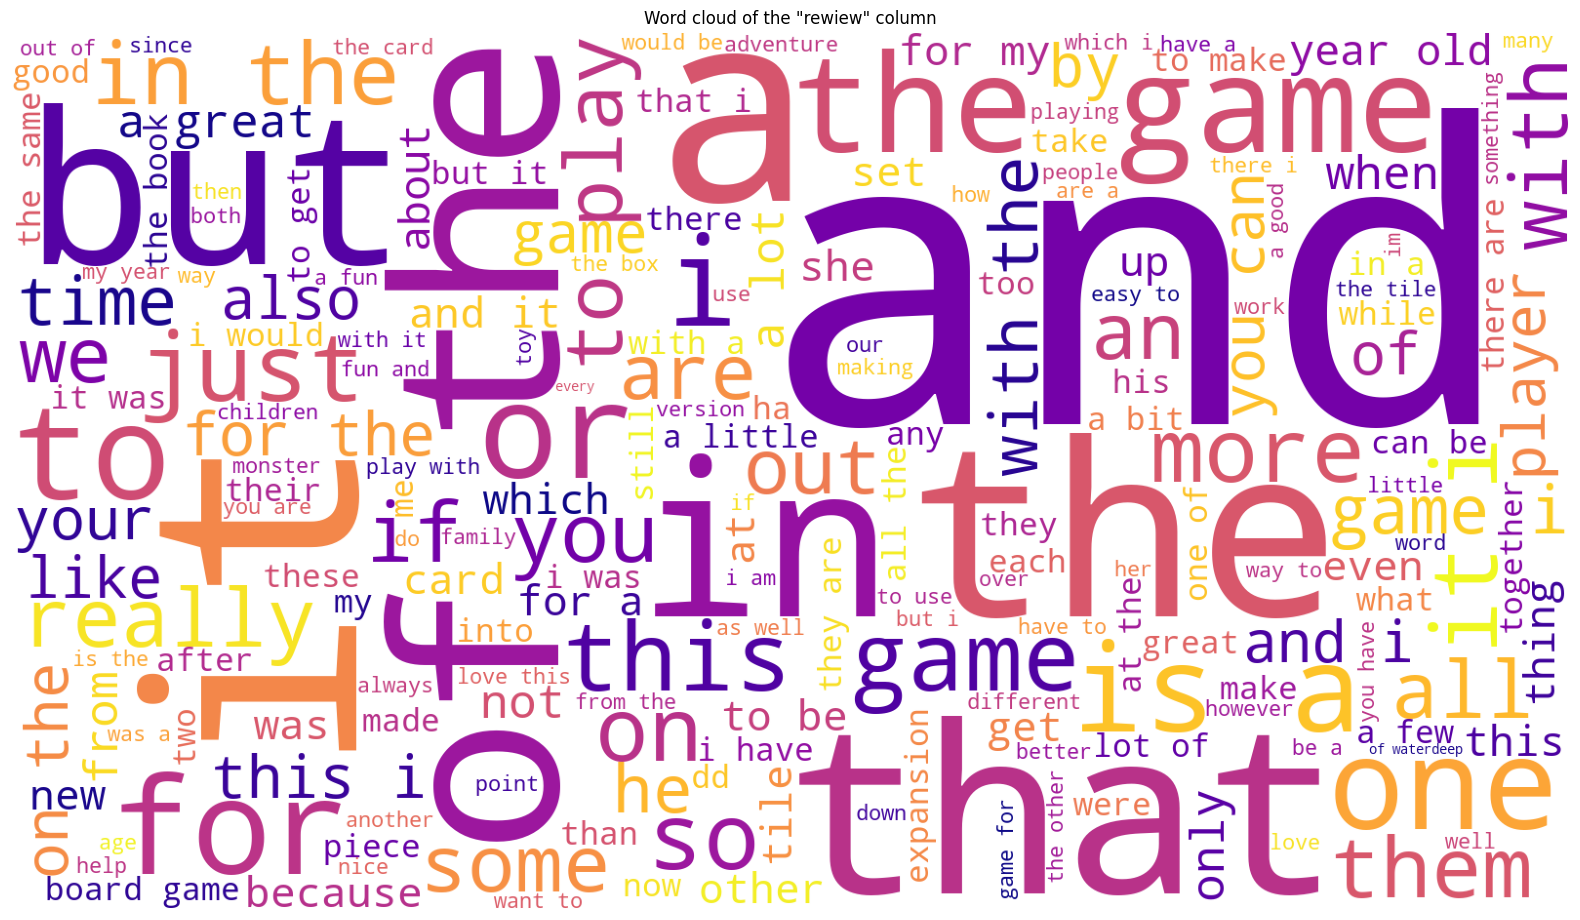

In [233]:
# Review: Plot the WordCloud image.
plt.figure(figsize = (16, 9), facecolor = None) 
plt.imshow(Review_word_cloud) 
plt.title('Word cloud of the "rewiew" column')
plt.axis('off') 
plt.tight_layout(pad = 0) 
plt.show()

In [94]:
# Summary: Create a word cloud.
summary_string = ''
for i in range(df3_copy.shape[0]):
    
# Add all comments
    summary_string = summary_string + df3_copy['summary'][i]

Summary_word_cloud = WordCloud(width = 1600, height = 900, 
                background_color ='white',
                colormap = 'plasma', 
                stopwords = 'none',
                min_font_size = 10).generate(summary_string) 

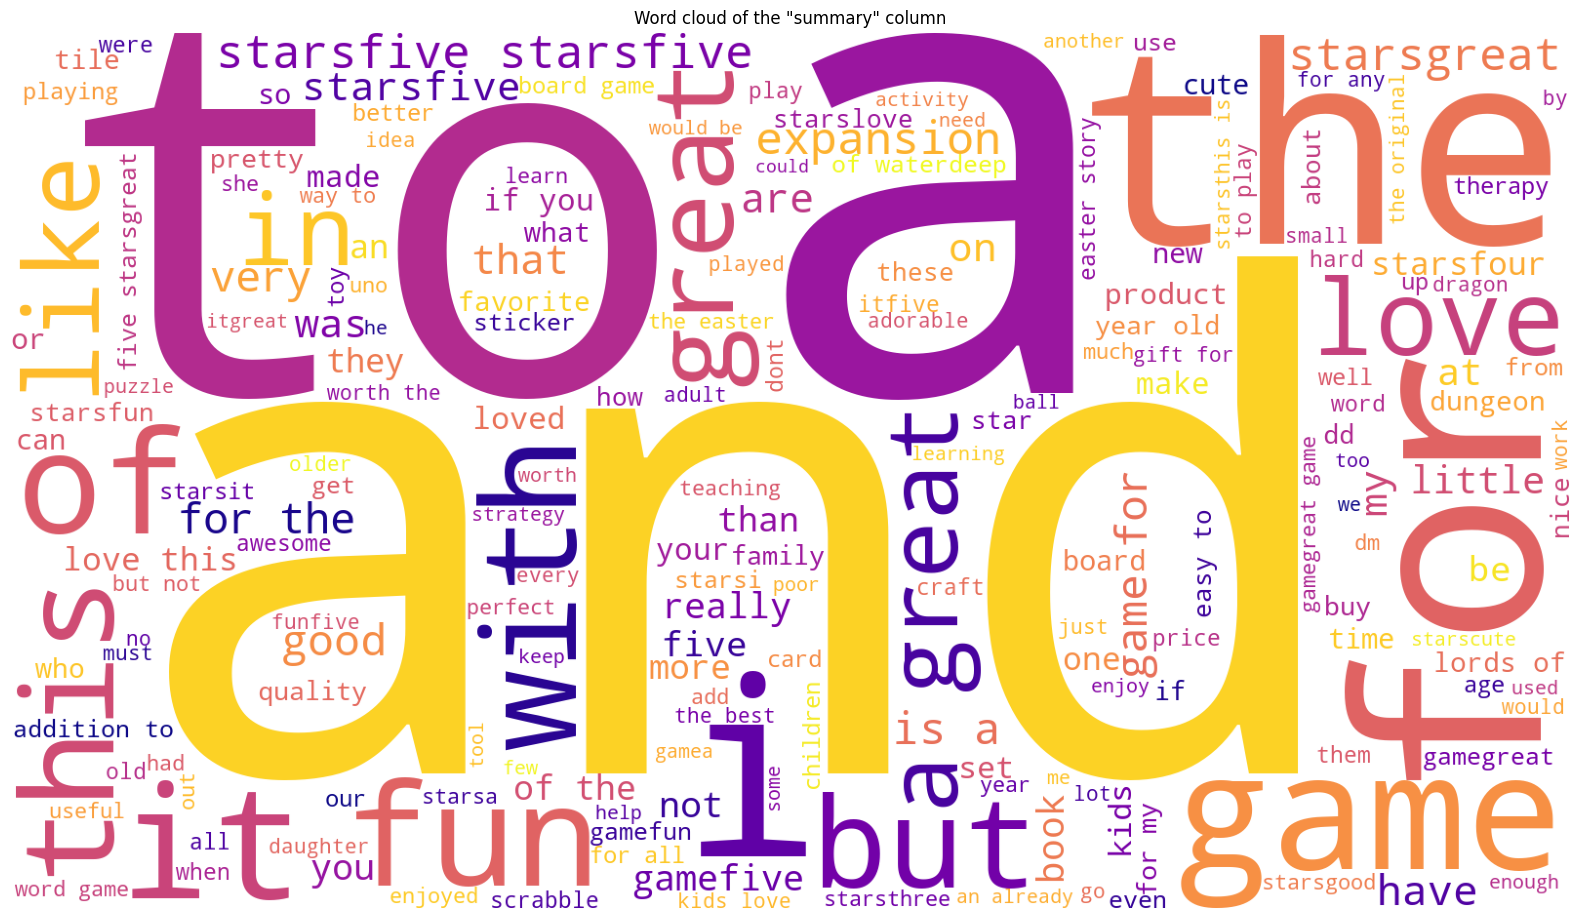

In [234]:
# Summary: Plot the WordCloud image.
plt.figure(figsize = (16, 9), facecolor = None) 
plt.imshow(Summary_word_cloud) 
plt.title('Word cloud of the "summary" column')
plt.axis('off') 
plt.tight_layout(pad = 0) 
plt.show()

## 4. Frequency distribution and polarity
### 4a) Create frequency distribution

In [97]:
# Determine the frequency distribution.
from nltk.probability import FreqDist

FreqDist({'the': 5451, 'and': 3233, 'to': 3162, 'a': 3160, 'of': 2488, 'i': 2090, 'it': 2083, 'is': 1782, 'this': 1776, 'game': 1671, ...})

In [98]:
# Frequency distribution in the "review" column
review_all = []

for i in range(df3_copy.shape[0]):
# Add each token to the list.
    review_all = review_all + df3_copy['review_tokenised'][i]

# Create a frequency distribution object for Reviews
freq_dist_review = FreqDist(review_all)

# Show the most common elements in Reviews
freq_dist_review

FreqDist({'the': 5451, 'and': 3233, 'to': 3162, 'a': 3160, 'of': 2488, 'i': 2090, 'it': 2083, 'is': 1782, 'this': 1776, 'game': 1671, ...})

In [99]:
# Frequency distribution in the "summary" column
summary_all = []

for i in range(df3_copy.shape[0]):
# Add each token to the list.
    summary_all = summary_all + df3_copy['summary_tokenised'][i]

# Create a frequency distribution object for Reviews
freq_dist_summary = FreqDist(summary_all)

# Show the most common elements in Reviews
freq_dist_summary

FreqDist({'stars': 427, 'five': 342, 'game': 319, 'great': 295, 'the': 261, 'a': 240, 'for': 232, 'fun': 218, 'to': 192, 'and': 168, ...})

### 4b) Remove alphanumeric characters and stopwords

In [105]:
# Delete all the alphanumeric characters.
review_no_alphanum = [word for word in review_all if word.isalnum()]
summary_no_alphanum = [word for word in summary_all if word.isalnum()]

In [106]:
# Remove all the stopwords in the "review_no_alphanum" column
english_stopwords = set(stopwords.words('english'))

# Create a filtered list of tokens without stopwords for Review
tokens_review_filtered = [x for x in review_no_alphanum if x.lower() not in english_stopwords]

# Define an empty string variable.
tokens_review_string = ''

#for value in tokens_review_alpanum:
for value in tokens_review_filtered:
    # Add each filtered token word to the string.
    tokens_review_string = tokens_review_string + value + ' '

In [107]:
# Remove all the stopwords in the "summary_no_alphanum" column
english_stopwords = set(stopwords.words('english'))

# Create a filtered list of tokens without stopwords for summary_no_alphanum
tokens_summary_filtered = [x for x in summary_no_alphanum if x.lower() not in english_stopwords]

# Define an empty string variable.
tokens_summary_string = ''

#for value in tokens_summary_alpanum:
for value in tokens_summary_filtered:
    # Add each filtered token word to the string.
    tokens_summary_string = tokens_summary_string + value + ' '

### 4c) Create wordcloud without stopwords

In [108]:
# Create a wordcloud without stop words for tokens_review_string.
wordcloud_review_filtered = WordCloud(width = 1600, height = 900, 
                background_color ='white', 
                colormap='plasma', 
                min_font_size = 10).generate(tokens_review_string) 

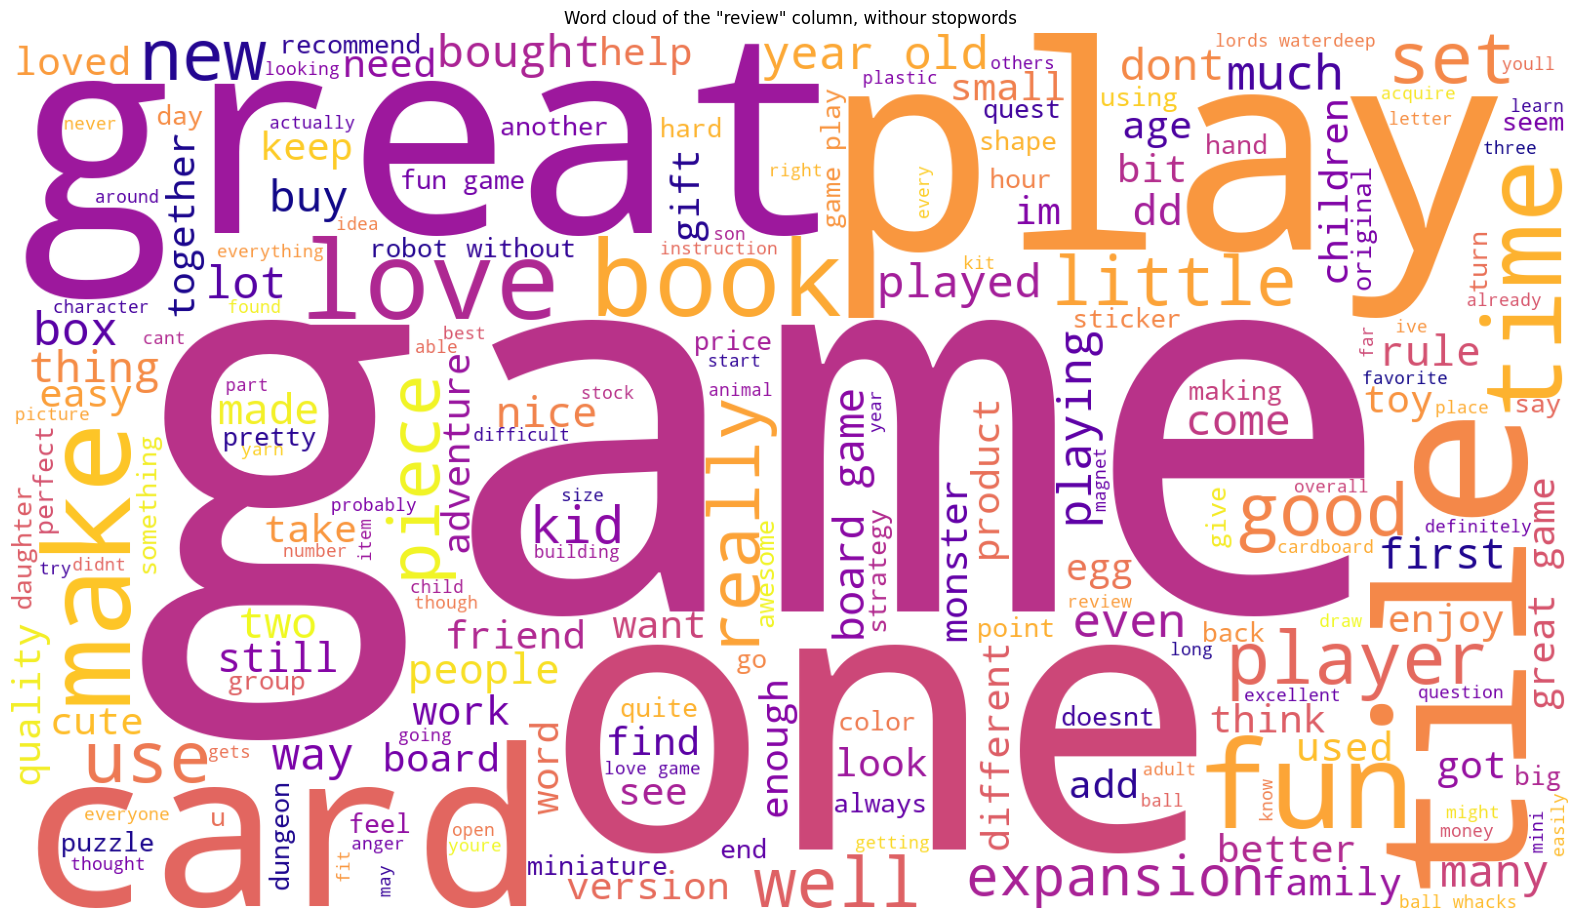

In [235]:
# Plot the wordcloud image.
plt.figure(figsize = (16, 9), facecolor = None) 
plt.imshow(wordcloud_review_filtered) 
plt.title('Word cloud of the "review" column, withour stopwords')
plt.axis('off') 
plt.tight_layout(pad = 0) 
plt.show()

In [112]:
# Create a wordcloud without stop words for tokens_summary_filtered
wordcloud_summary_filtered = WordCloud(width = 1600, height = 900, 
                background_color ='white', 
                colormap='plasma', 
                min_font_size = 10).generate(tokens_summary_string) 

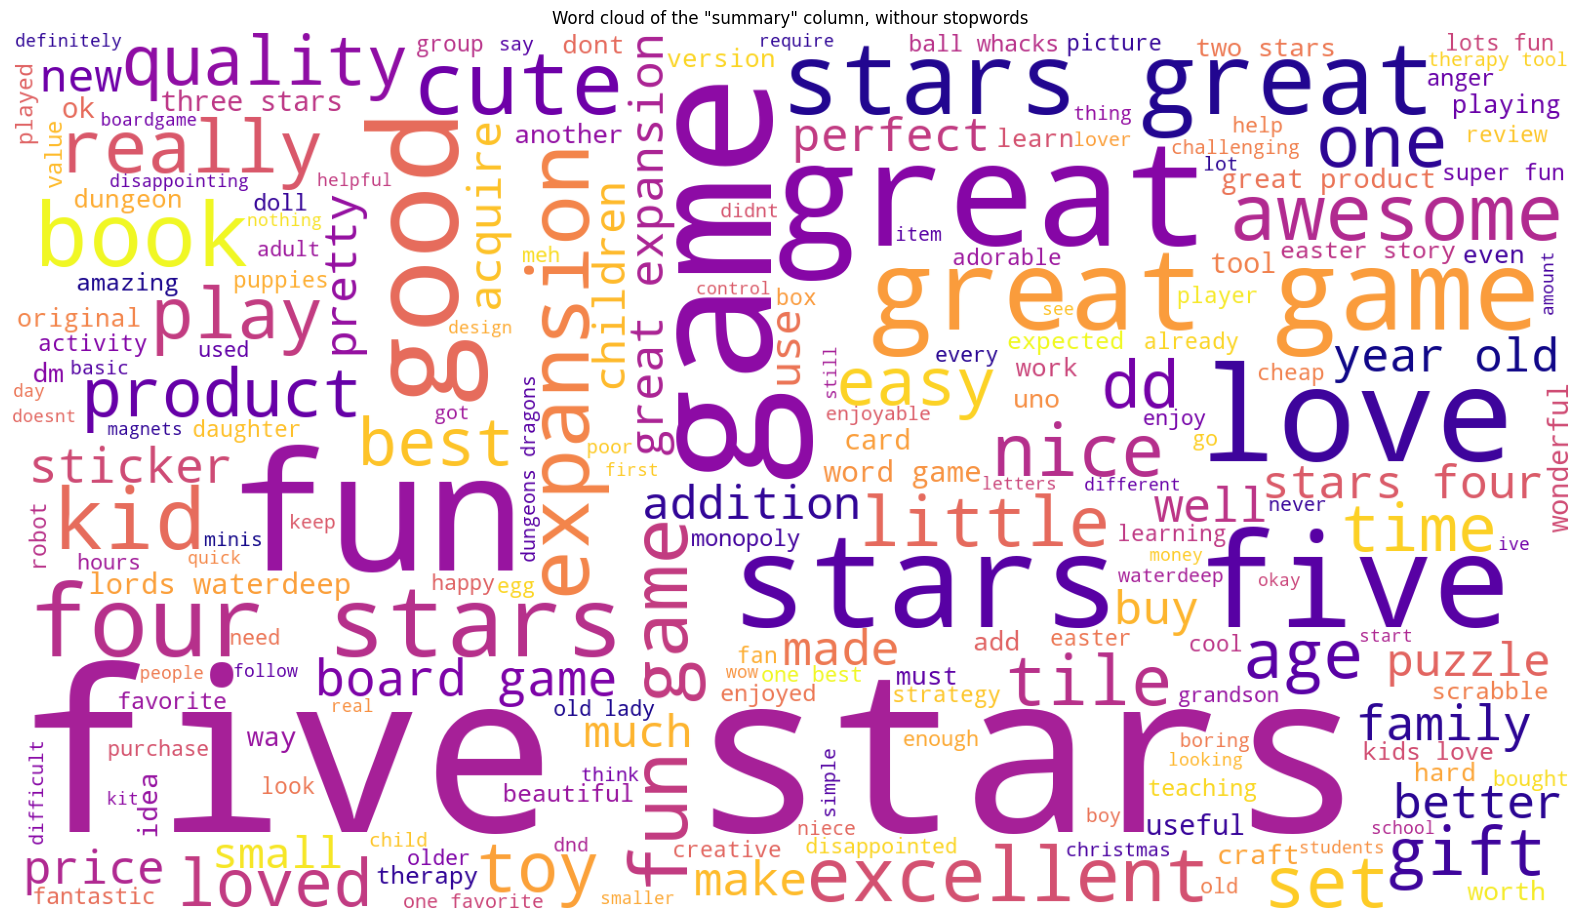

In [238]:
# Plot the wordcloud image.
plt.figure(figsize = (16, 9), facecolor = None) 
plt.imshow(wordcloud_summary_filtered) 
plt.title('Word cloud of the "summary" column, withour stopwords')
plt.axis('off') 
plt.tight_layout(pad = 0) 
plt.show()

### 4d) Identify 15 most common words and polarity for review

In [114]:
# Determine the 15 most common words for review.
freq_review = FreqDist(tokens_review_filtered)

# Preview the data.
freq_review

FreqDist({'game': 1671, 'great': 580, 'fun': 552, 'one': 530, 'play': 502, 'like': 414, 'love': 323, 'really': 319, 'get': 319, 'cards': 301, ...})

In [115]:
# Import the Counter class.
from collections import Counter

# Generate a DataFrame from tokens_review_filtered
review_counts = pd.DataFrame(Counter(tokens_review_filtered).most_common(15),
                      columns=['Word', 'Frequency']).set_index('Word')

# Preview data.
review_counts

,Frequency
Word,
game,1671
great,580
fun,552
one,530
play,502
like,414
love,323
really,319
get,319


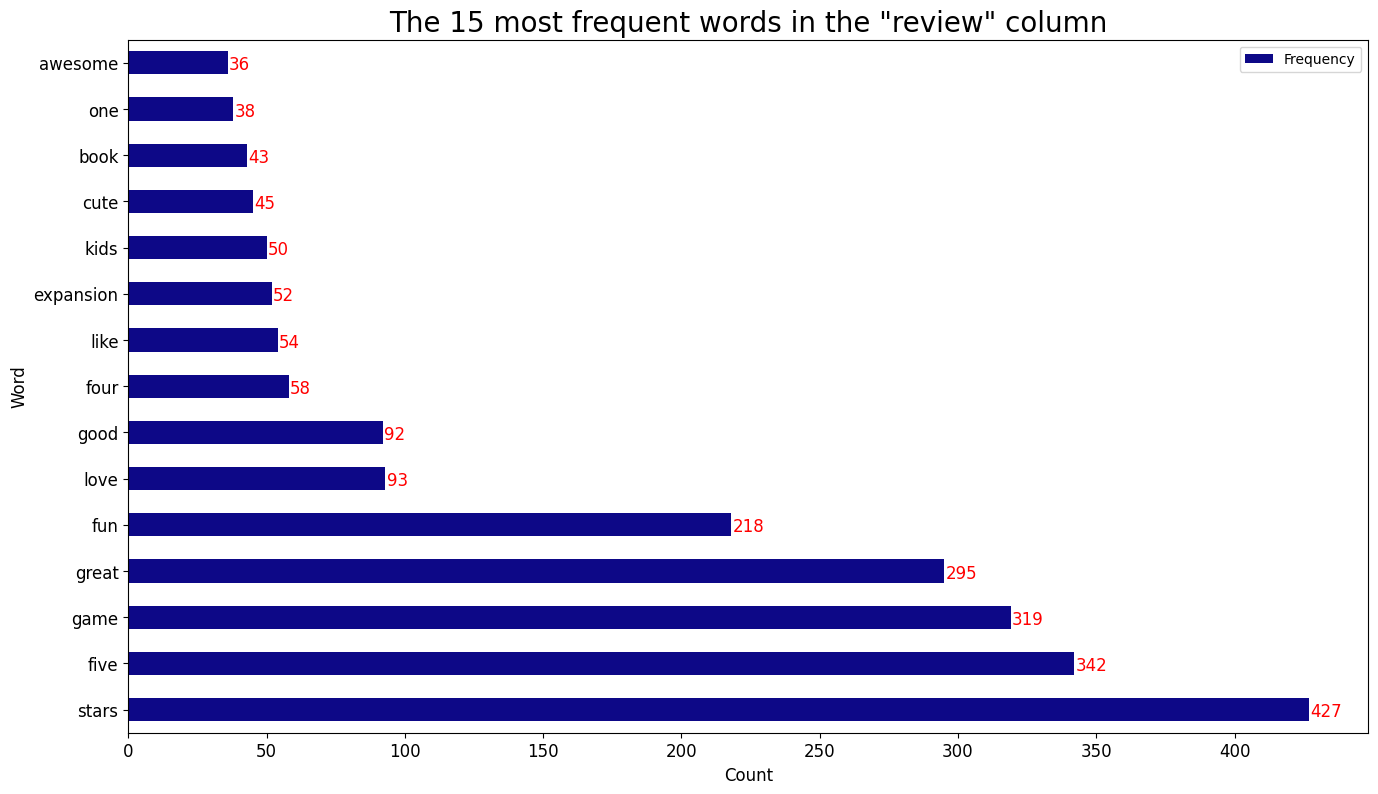

In [125]:
# Set the plot type.
ax = review_counts.plot(kind='barh', figsize=(16, 9), fontsize=12,
                 colormap ='plasma')

# Set the labels.
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Word', fontsize=12)
ax.set_title("The 15 most frequent words in the \"review\" column",
             fontsize=20)

# Draw the bar labels.
for i in ax.patches:
    ax.text(i.get_width()+.41, i.get_y()+.1, str(round((i.get_width()), 2)),
            fontsize=12, color='red')

### 4e) Identify 15 most common words and polarity for summary

In [118]:
# Determine the 15 most common words for summary.
freq_review = FreqDist(tokens_summary_filtered)

# Preview the data.
freq_review

FreqDist({'stars': 427, 'five': 342, 'game': 319, 'great': 295, 'fun': 218, 'love': 93, 'good': 92, 'four': 58, 'like': 54, 'expansion': 52, ...})

In [122]:
# Import the Counter class.
from collections import Counter

# Generate a DataFrame from tokens_summary_filtered
summary_counts = pd.DataFrame(Counter(tokens_summary_filtered).most_common(15),
                      columns=['Word', 'Frequency']).set_index('Word')

# Preview data.
summary_counts

,Frequency
Word,
stars,427
five,342
game,319
great,295
fun,218
love,93
good,92
four,58
like,54


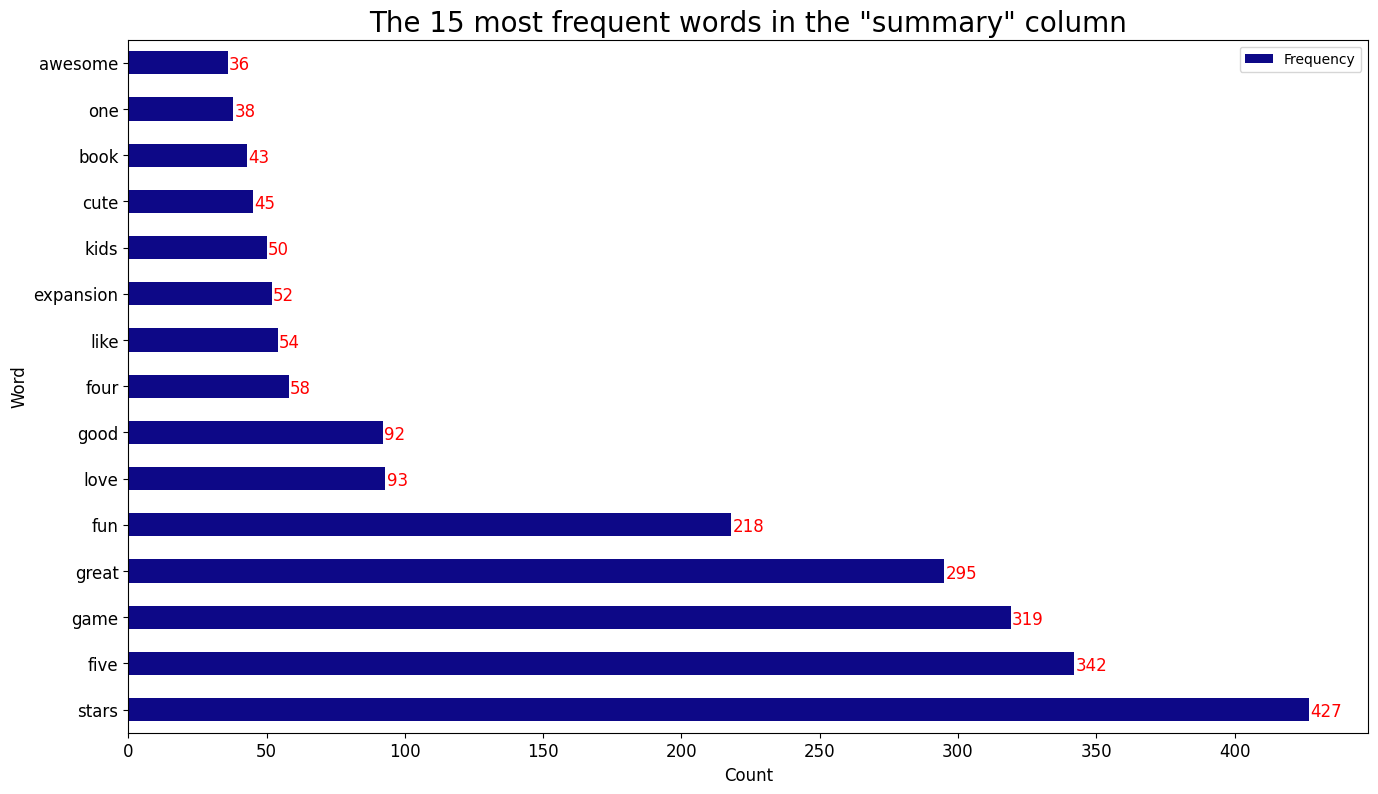

In [126]:
# Set the plot type.
ax = summary_counts.plot(kind='barh', figsize=(16, 9), fontsize=12,
                 colormap ='plasma')

# Set the labels.
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Word', fontsize=12)
ax.set_title("The 15 most frequent words in the \"summary\" column",
             fontsize=20)

# Draw the bar labels.
for i in ax.patches:
    ax.text(i.get_width()+.41, i.get_y()+.1, str(round((i.get_width()), 2)),
            fontsize=12, color='red')

## 5. Review polarity and sentiment: Plot histograms of polarity (use 15 bins) and sentiment scores for the respective columns.

In [202]:
# Import the necessary package
from textblob import TextBlob

# Provided function.
def generate_polarity(comment):
    '''Extract polarity score (-1 to +1) for each comment'''
    return TextBlob(comment).sentiment[0]

In [187]:
# Determine polarity of both columns. 

# Populate a new column with polarity scores for each review.
df3['polarity_review'] = df3['review'].apply(generate_polarity)

# Populate a new column with polarity scores for each summary.
df3['polarity_summary'] = df3['summary'].apply(generate_polarity)

# View output.
print(df3['polarity_review'].head())
print()
print(df3['polarity_summary'].head())

0   -0.036111
1    0.035952
2    0.116640
3    0.578788
4   -0.316667
Name: polarity_review, dtype: float64

0    0.15
1   -0.80
2    0.00
3    0.00
4    0.00
Name: polarity_summary, dtype: float64


### 5a) Histograms of polarity and sentiment scores for the "review" column.

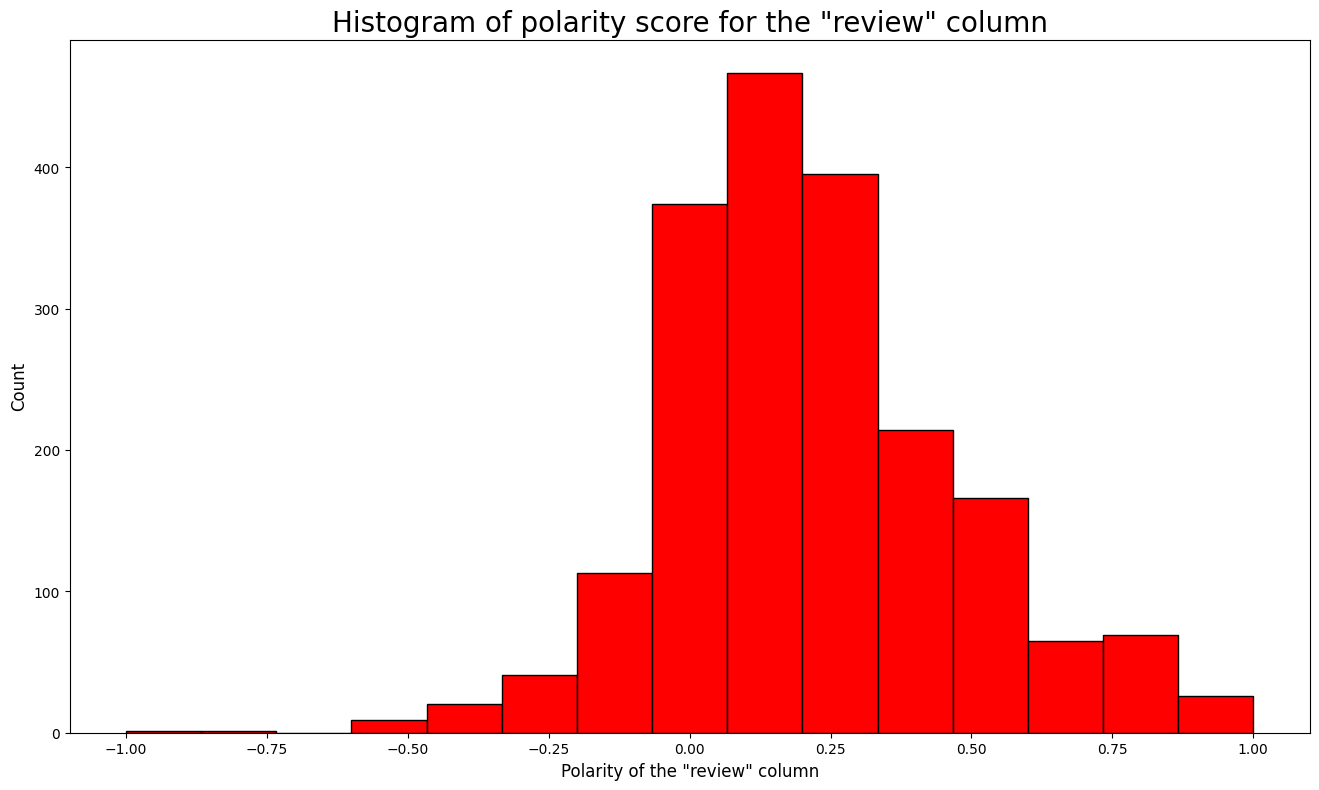

In [229]:
# Review: Create a histogram plot with bins = 15.

# Histogram of polarity scores for the "review" column.

# Set the number of bins.
num_bins = 15

# Set the plot area.
plt.figure(figsize=(16,9))

# Define the bars.
n, bins, patches = plt.hist(df3['polarity_review'], num_bins, edgecolor='black', facecolor='red', alpha=1.0)

# Histogram of sentiment score
plt.xlabel('Polarity of the "review" column', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Histogram of polarity score for the \"review\" column', fontsize=20)

plt.show()

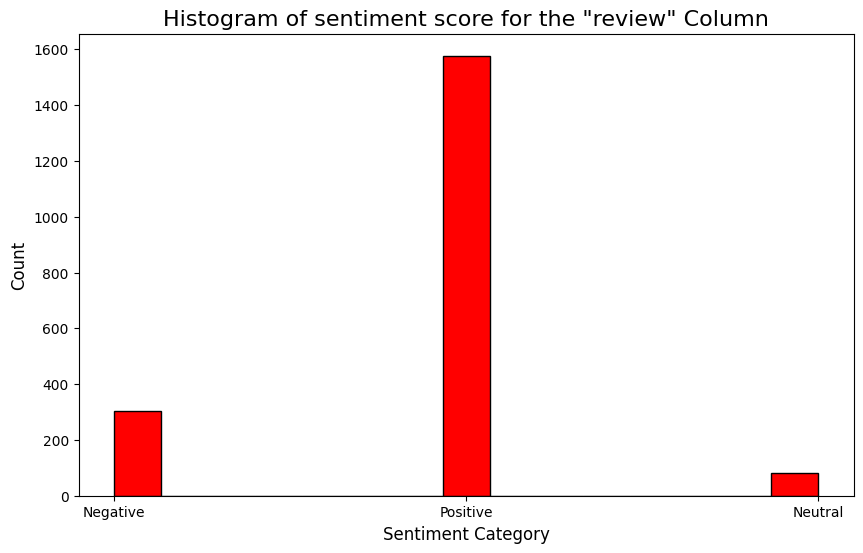

In [230]:
# Histogram of sentiment score for the "review" column.

# Import necessary libraries
import matplotlib.pyplot as plt

# Classify each review as positive, negative, or neutral based on polarity.
df3['sentiment_review'] = df3['polarity_review'].apply(lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral'))
df3['sentiment_review'].value_counts()

# Set the number of bins.
num_bins = 15

# Set the plot area.
plt.figure(figsize=(10, 6))

# Define the bars.
n, bins, patches = plt.hist(df3['sentiment_review'], num_bins, edgecolor='black', facecolor='red', alpha=1.0)

# Add labels and title.
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Histogram of sentiment score for the "review" Column', fontsize=16)

# Display the plot.
plt.show()

### 5a) Histograms of polarity and sentiment scores for the "summary" column.

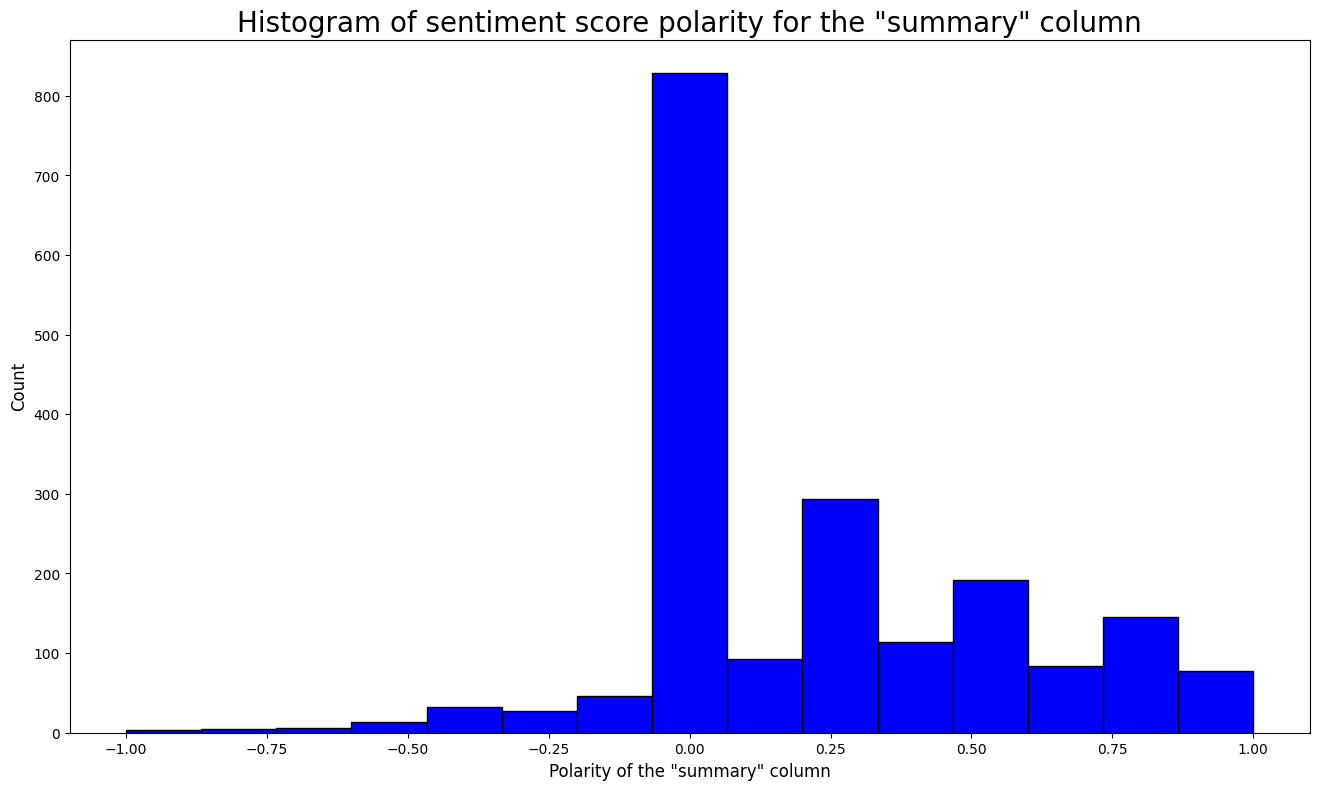

In [185]:
# Summary: Create a histogram plot with bins = 15.
# Histogram of polarity 

# Set the number of bins.
num_bins = 15

# Set the plot area.
plt.figure(figsize=(16,9))

# Define the bars.
n, bins, patches = plt.hist(df3['polarity_summary'], num_bins, edgecolor='black', facecolor='blue', alpha=1.0)

# Histogram of sentiment score
plt.xlabel('Polarity of the "summary" column', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Histogram of sentiment score polarity for the \"summary\" column', fontsize=20)

plt.show()

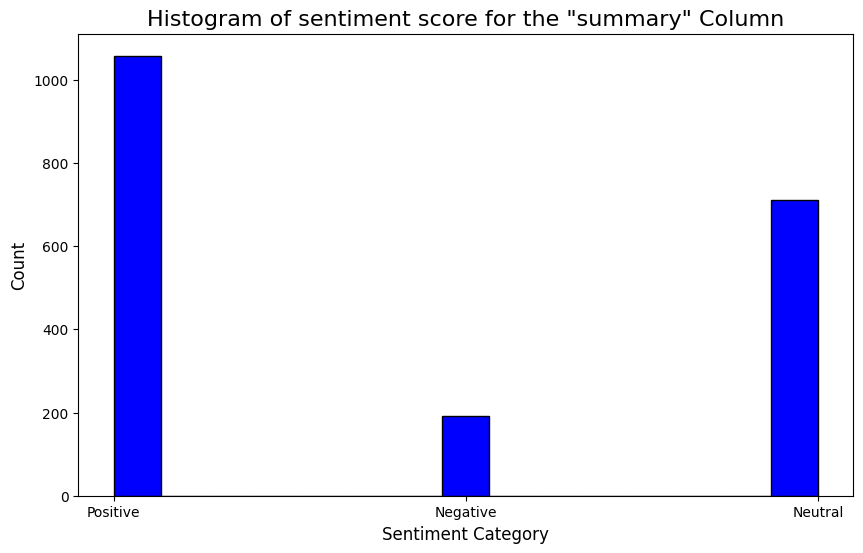

In [237]:
# Histogram of sentiment score for the "summary" column.

# Import necessary libraries
import matplotlib.pyplot as plt

# Classify each review as positive, negative, or neutral based on polarity.
df3['sentiment_summary'] = df3['polarity_summary'].apply(lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral'))
df3['sentiment_summary'].value_counts()

# Set the number of bins.
num_bins = 15

# Set the plot area.
plt.figure(figsize=(10, 6))

# Define the bars.
n, bins, patches = plt.hist(df3['sentiment_summary'], num_bins, edgecolor='black', facecolor='blue', alpha=1.0)

# Add labels and title.
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Histogram of sentiment score for the "summary" Column', fontsize=16)

# Display the plot.
plt.show()

## 6. Identify top 20 positive and negative reviews and summaries respectively

In [201]:
# Top 20 negative reviews.
# Create a DataFrame.
negative_review = df3.nsmallest(20, 'polarity_review')

# Eliminate unnecessary columns.
negative_review = negative_review[['review']]

# View output
# Adjust the column width.
negative_review.style.set_properties(subset=['review'], **{'width': '1200px'})

,review
207,booo unles you are patient know how to measure i didnt have the patience neither did my daughter boring unless you are a craft person which i am not
181,incomplete kit very disappointing
1773,im sorry i just find this product to be boring and to be frank juvenile
362,one of my staff will be using this game soon so i dont know how well it works as yet but after looking at the cards i believe it will be helpful in getting a conversation started regarding anger and what to do to control it
116,i bought this as a christmas gift for my grandson its a sticker book so how can i go wrong with this gift
226,this was a gift for my daughter i found it difficult to use
229,i found the directions difficult
289,instructions are complicated to follow
300,difficult
1501,expensive for what you get


In [200]:
# Top 20 negative summaries.
# Create a DataFrame.
negative_summary = df3.nsmallest(20, 'polarity_summary')

# Eliminate unnecessary columns.
negative_summary = negative_summary[['summary']]

# View output
# Adjust the column width.
negative_summary.style.set_properties(subset=['summary'], **{'width': '1200px'})

,summary
21,the worst value ive ever seen
207,boring unless you are a craft person which i am
819,boring
1148,before this i hated running any rpg campaign dealing with towns because it
1,another worthless dungeon masters screen from galeforce9
143,disappointed
623,disappointed
785,disappointed
1591,disappointed
361,promotes anger instead of teaching calming methods


In [198]:
# Top 20 positive reviews.
# Create a DataFrame.
positive_reviews = df3.nlargest(20, 'polarity_review')

# Eliminate unnecessary columns.
positive_reviews = positive_reviews[['review']]

# View output
# Adjust the column width.
positive_reviews.style.set_properties(subset=['review'], **{'width': '1200px'})

,review
7,came in perfect condition
164,awesome book
193,awesome gift
489,excellent activity for teaching selfmanagement skills
517,perfect just what i ordered
583,wonderful product
601,delightful product
613,wonderful for my grandson to learn the resurrection story
782,perfect
923,awesome


In [199]:
# Top 20 positive summaries.
# Create a DataFrame.
positive_summary = df3.nlargest(20, 'polarity_summary')

# Eliminate unnecessary columns.
positive_summary = positive_summary[['summary']]

# View output
# Adjust the column width.
positive_summary.style.set_properties(subset=['summary'], **{'width': '1200px'})

,summary
6,best gm screen ever
28,wonderful designs
32,perfect
80,theyre the perfect size to keep in the car or a diaper
133,perfect for preschooler
139,awesome sticker activity for the price
160,awesome book
162,he was very happy with his gift
186,awesome
209,awesome and welldesigned for 9 year olds


## 7. Discuss: Insights and observations

In the reviews, the most popular word is "game", followed by "great", "fun", "one", "play", all positive or natural words. 
Soimilarly, in the summaries, the most popular word is "star", followed by "five", "game", "great", "fun", still positive or natural words.

The polarity and sentiment histograms confirm that both reviews and summeries have strong positive scores. In the reviews, the predominancy of positive words in strong, towards neutral and negative words. In the summaries, there is a high number of neutral words, but still lower than the positive ones. 

Overall, it is possible to conclude that Turtle Games is doing a great jog, in promoting its products, as the above analysis shows. Turtle Games could use this positive vibe for their marketing campaigns, by adopting positive words in their commercials. On the other hand, a deeped study in the negative words and their frequency could help address and improve some issues. 

# 